In [1]:
import requests
import pandas as pd
import numpy as np
from io import StringIO
import time
from pathlib import Path
from datetime import datetime,timezone
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import json
import os

print("Libraries imported successfully.")

Libraries imported successfully.


### 1st data fetching source Historical Data

In [2]:
histo_df = pd.read_csv("all data/Historical_data.csv")

### 2nd source data feting USGS data fetching

In [3]:
# ============================================================
# USGS CONFIGURATION
# ============================================================

INDIA = {
    "minlatitude": 6.4,
    "maxlatitude": 35.5,
    "minlongitude": 68.7,
    "maxlongitude": 97.4
}

USGS_URL = "https://earthquake.usgs.gov/fdsnws/event/1/query"

MIN_MAGNITUDE = 3.0

# Output location
OUTPUT_DIR = Path("all data/usgs_india_full.csv")
OUTPUT_FILE = OUTPUT_DIR / "usgs_india_2019_present.csv"

In [4]:
# ============================================================
# INCREMENTAL USGS FETCH — FIND LAST SAVED EVENT
# ============================================================

USGS_MASTER_PATH = r"all data/usgs_india_full.csv"

# Load existing data
if os.path.exists(USGS_MASTER_PATH):

    usgs_existing = pd.read_csv(
        USGS_MASTER_PATH
    )

    print("=" * 70)
    print("IDIP — EXISTING USGS DATA CHECK")
    print("=" * 70)

    print(
        "Existing records:",
        len(usgs_existing)
    )

    # Ensure datetime
    usgs_existing["time"] = pd.to_datetime(
        usgs_existing["time"],
        errors="coerce",
        utc=True
    )

    last_event_time = usgs_existing["time"].max()

    print(
        "Latest saved event:",
        last_event_time
    )

else:

    print("=" * 70)
    print("IDIP — NO EXISTING USGS MASTER FOUND")
    print("=" * 70)

    usgs_existing = pd.DataFrame()

    # First-time fetch starting point
    last_event_time = pd.Timestamp(
        "2019-01-01",
        tz="UTC"
    )

    print(
        "Starting from:",
        last_event_time
    )

IDIP — EXISTING USGS DATA CHECK
Existing records: 2732
Latest saved event: 2026-08-11 19:55:41.269000+00:00


In [5]:
# ============================================================
# DEFINE INCREMENTAL FETCH WINDOW
# ============================================================

FETCH_START = (
    last_event_time
    + pd.Timedelta(milliseconds=1)
)

FETCH_END = pd.Timestamp.now(
    tz="UTC"
)

print("=" * 70)
print("IDIP — USGS INCREMENTAL FETCH WINDOW")
print("=" * 70)

print("Fetch start:", FETCH_START)
print("Fetch end  :", FETCH_END)

IDIP — USGS INCREMENTAL FETCH WINDOW
Fetch start: 2026-08-11 19:55:41.270000+00:00
Fetch end  : 2026-08-22 01:57:49.562798+00:00


In [6]:
# ============================================================
# CREATE INCREMENTAL FETCH CHUNKS
# ============================================================

DATE_CHUNKS = []

current_start = FETCH_START

while current_start < FETCH_END:

    # End of current year
    year_end = pd.Timestamp(
        f"{current_start.year}-12-31 23:59:59.999",
        tz="UTC"
    )

    current_end = min(
        year_end,
        FETCH_END
    )

    DATE_CHUNKS.append(
        (
            current_start,
            current_end
        )
    )

    current_start = (
        current_end
        + pd.Timedelta(milliseconds=1)
    )


print("=" * 70)
print("IDIP — USGS INCREMENTAL FETCH CHUNKS")
print("=" * 70)

print("Chunks created:", len(DATE_CHUNKS))

for start, end in DATE_CHUNKS:
    print(
        f"{start} → {end}"
    )

IDIP — USGS INCREMENTAL FETCH CHUNKS
Chunks created: 1
2026-08-11 19:55:41.270000+00:00 → 2026-08-22 01:57:49.562798+00:00


In [7]:
# ============================================================
# USGS INCREMENTAL FETCH FUNCTION
# ============================================================

def fetch_usgs_chunk(
    start,
    end,
    max_retries=3
):
    params = {
        "format": "csv",
        "starttime": (
            start.isoformat()
        ),
        "endtime": (
            end.isoformat()
        ),
        "minlatitude": INDIA["minlatitude"],
        "maxlatitude": INDIA["maxlatitude"],
        "minlongitude": INDIA["minlongitude"],
        "maxlongitude": INDIA["maxlongitude"],
        "minmagnitude": MIN_MAGNITUDE,
        "orderby": "time-asc",
        "limit": 20000
    }

    for attempt in range(
        1,
        max_retries + 1
    ):
        try:
            response = requests.get(
                USGS_URL,
                params=params,
                timeout=60
            )
            response.raise_for_status()
            df = pd.read_csv(
                StringIO(response.text)
            )
            print(
                f"✔ {start} → {end} "
                f"| {len(df):,} records"
            )
            return df
        except requests.RequestException as error:
            print(
                f"⚠ Attempt "
                f"{attempt}/{max_retries} failed "
                f"for {start} → {end}"
            )
            print(
                f"Error: {error}"
            )
            if attempt < max_retries:
                time.sleep(5)
            else:
                print(
                    f"✘ Failed permanently: "
                    f"{start} → {end}"
                )
                return pd.DataFrame()

In [8]:
# ============================================================
# INCREMENTAL USGS FETCH
# ============================================================

all_usgs_chunks = []

print("=" * 70)
print("IDIP — STARTING INCREMENTAL USGS FETCH")
print("=" * 70)

if FETCH_START >= FETCH_END:
    print(
        "USGS data is already up to date."
    )
    usgs_new = pd.DataFrame()
else:
    for start, end in DATE_CHUNKS:
        df = fetch_usgs_chunk(
            start,
            end
        )
        if not df.empty:
            all_usgs_chunks.append(df)
        time.sleep(2)

    if all_usgs_chunks:
        usgs_new = pd.concat(
            all_usgs_chunks,
            ignore_index=True
        )
    else:
        usgs_new = pd.DataFrame()

print()
print("=" * 70)
print("IDIP — INCREMENTAL USGS FETCH COMPLETE")
print("=" * 70)

print(
    "New records fetched:",
    len(usgs_new)
)

IDIP — STARTING INCREMENTAL USGS FETCH
✔ 2026-08-11 19:55:41.270000+00:00 → 2026-08-22 01:57:49.562798+00:00 | 4 records

IDIP — INCREMENTAL USGS FETCH COMPLETE
New records fetched: 4


In [9]:
# ============================================================
# MERGE EXISTING + NEW USGS DATA
# ============================================================

if not usgs_new.empty:
    usgs_raw = pd.concat(
        [
            usgs_existing,
            usgs_new
        ],
        ignore_index=True
    )
else:
    usgs_raw = usgs_existing.copy()

records_before = len(usgs_raw)

# ------------------------------------------------------------
# DUPLICATE PROTECTION
# ------------------------------------------------------------

if "id" in usgs_raw.columns:
    usgs_raw = (
        usgs_raw
        .drop_duplicates(
            subset=["id"],
            keep="last"
        )
        .reset_index(drop=True)
    )
else:
    usgs_raw = (
        usgs_raw
        .drop_duplicates()
        .reset_index(drop=True)
    )

records_after = len(usgs_raw)
print("=" * 70)
print("IDIP — USGS MASTER UPDATE")
print("=" * 70)
print(
    "Existing records :",
    len(usgs_existing)
)
print(
    "New records      :",
    len(usgs_new)
)
print(
    "Before dedup     :",
    records_before
)
print(
    "Final records    :",
    records_after
)
print(
    "Duplicates removed:",
    records_before - records_after
)

IDIP — USGS MASTER UPDATE
Existing records : 2732
New records      : 4
Before dedup     : 2736
Final records    : 2732
Duplicates removed: 4


In [10]:
# ============================================================
# SAVE UPDATED USGS MASTER
# ============================================================

usgs_raw.to_csv(
    USGS_MASTER_PATH,
    index=False
)

print("=" * 70)
print("IDIP — USGS MASTER SAVED")
print("=" * 70)

print(
    "File:",
    USGS_MASTER_PATH
)

print(
    "Total records:",
    len(usgs_raw)
)

IDIP — USGS MASTER SAVED
File: all data/usgs_india_full.csv
Total records: 2732


In [13]:
usgs_raw["time"] = pd.to_datetime(
    usgs_raw["time"],
    errors="coerce",
    utc=True
)

print("Date range:")
print(usgs_raw["time"].min())
print(usgs_raw["time"].max())

Date range:
2019-01-03 14:03:44.980000+00:00
2026-08-21 21:54:47.902000+00:00


# 3rd data source feting GDACS Data Fetching

In [14]:
# ============================================================
# GDACS — CONFIGURATION
# ============================================================

GDACS_URL = (
    "https://www.gdacs.org/"
    "gdacsapi/api/events/geteventlist/SEARCH"
)

START_YEAR = 2019
END_DATE = datetime.now(timezone.utc).strftime("%Y-%m-%d")
EVENT_TYPES = "FL,TC,VO,WF,DR"
COUNTRY = "IND"
PAGE_SIZE = 100
OUTPUT_DIR = Path("data/raw/gdacs")
OUTPUT_FILE = (
    OUTPUT_DIR /
    "gdacs_india_2019_present.csv"
)

print("GDACS configuration loaded.")
print("Mode: Incremental update")
print("Data range: Last stored event → Current date")
print(f"Event types: {EVENT_TYPES}")
print(f"Country: {COUNTRY}")

GDACS configuration loaded.
Mode: Incremental update
Data range: Last stored event → Current date
Event types: FL,TC,VO,WF,DR
Country: IND


In [15]:
# ============================================================
# GDACS FETCH FUNCTION
# ============================================================

def fetch_gdacs_chunk(
    start,
    end,
    max_retries=3
):
    all_records = []
    page = 1

    while True:
        params = {
            "eventtypes": EVENT_TYPES,
            "fromDate": start,
            "toDate": end,
            "country": COUNTRY,
            "pagesize": PAGE_SIZE,
            "pagenumber": page
        }
        success = False
        for attempt in range(1, max_retries + 1):
            try:
                response = requests.get(
                    GDACS_URL,
                    params=params,
                    timeout=60
                )
                response.raise_for_status()
                data = response.json()
                success = True
                break
            except (
                requests.RequestException,
                ValueError
            ) as error:
                print(
                    f"⚠ Attempt {attempt}/{max_retries} failed "
                    f"for {start} → {end}"
                )
                print(f"   Error: {error}")
                if attempt < max_retries:
                    time.sleep(5)

        # Stop this chunk if all retries fail
        if not success:
            print(
                f"❌ Failed permanently: "
                f"{start} → {end} | Page {page}"
            )
            break

        # Extract features
        features = data.get(
            "features",
            []
        )
        # No more records
        if not features:
            break

        # Process records
        for feature in features:
            properties = feature.get(
                "properties",
                {}
            ).copy()
            geometry = feature.get(
                "geometry",
                {}
            )
            coordinates = geometry.get(
                "coordinates",
                [None, None]
            )
            if (
                isinstance(coordinates, list)
                and len(coordinates) >= 2
            ):
                properties["longitude"] = coordinates[0]
                properties["latitude"] = coordinates[1]
            else:
                properties["longitude"] = None
                properties["latitude"] = None
                
            all_records.append(
                properties
            )

        print(
            f"✅ {start} → {end} | "
            f"Page {page} | "
            f"{len(features)} records"
        )

        # Check total available events
        total_events = data.get(
            "totalEvents",
            None
        )
        if total_events is not None:
            if page * PAGE_SIZE >= total_events:
                break

        elif len(features) < PAGE_SIZE:
            break
            
        page += 1
        time.sleep(1)
    return pd.DataFrame(all_records)

In [16]:
# ============================================================
# GDACS — LOAD EXISTING MASTER & FIND LAST EVENT
# ============================================================

GDACS_MASTER_FILE = Path(
    r"D:\codes\IDIP\all data\gdacs_india_full.csv"
)
if GDACS_MASTER_FILE.exists():
    gdacs_master = pd.read_csv(
        GDACS_MASTER_FILE
    )
    print(
        f"Existing GDACS master records: "
        f"{len(gdacs_master):,}"
    )
else:
    gdacs_master = pd.DataFrame()
    print(
        "No existing GDACS master found."
    )

# ------------------------------------------------------------
# Find latest stored event date
# ------------------------------------------------------------

if not gdacs_master.empty:
    gdacs_master["fromdate"] = pd.to_datetime(
        gdacs_master["fromdate"],
        errors="coerce",
        utc=True
    )
    last_gdacs_date = (
        gdacs_master["fromdate"].max()
    )
    print("\nLast stored GDACS event:")
    print(last_gdacs_date)
else:
    last_gdacs_date = pd.Timestamp(
        "2019-01-01",
        tz="UTC"
    )
    print(
        "\nNo previous records found."
    )
    print(
        "Starting GDACS fetch from 2019-01-01"
    )

Existing GDACS master records: 78

Last stored GDACS event:
2026-05-08 09:10:00+00:00


In [17]:
# ============================================================
# GDACS — DEFINE INCREMENTAL FETCH WINDOW
# ============================================================

GDACS_INCREMENTAL_START = (
    last_gdacs_date
    - pd.Timedelta(days=1)
)
GDACS_INCREMENTAL_END = pd.Timestamp.now(
    tz="UTC"
)
print("GDACS incremental fetch window:")
print(
    GDACS_INCREMENTAL_START.strftime("%Y-%m-%d"),
    "→",
    GDACS_INCREMENTAL_END.strftime("%Y-%m-%d")
)

GDACS incremental fetch window:
2026-05-07 → 2026-08-22


In [18]:
# ============================================================
# GDACS — CREATE INCREMENTAL DATE CHUNKS
# ============================================================

GDACS_INCREMENTAL_CHUNKS = []
chunk_start = GDACS_INCREMENTAL_START
while chunk_start <= GDACS_INCREMENTAL_END:
    year_end = pd.Timestamp(
        year=chunk_start.year,
        month=12,
        day=31,
        tz="UTC"
    )
    chunk_end = min(
        year_end,
        GDACS_INCREMENTAL_END
    )
    GDACS_INCREMENTAL_CHUNKS.append(
        (
            chunk_start.strftime("%Y-%m-%d"),
            chunk_end.strftime("%Y-%m-%d")
        )
    )
    chunk_start = (
        chunk_end
        + pd.Timedelta(days=1)
    )

print("Incremental chunks:")
for start, end in GDACS_INCREMENTAL_CHUNKS:
    print(f"{start} → {end}")

Incremental chunks:
2026-05-07 → 2026-08-22


In [19]:
# ============================================================
# GDACS — INCREMENTAL FETCH
# ============================================================

gdacs_incremental_chunks = []

for start, end in GDACS_INCREMENTAL_CHUNKS:
    df = fetch_gdacs_chunk(
        start,
        end
    )
    if not df.empty:
        gdacs_incremental_chunks.append(df)
        
    time.sleep(2)

if gdacs_incremental_chunks:
    gdacs_incremental = pd.concat(
        gdacs_incremental_chunks,
        ignore_index=True
    )
else:
    gdacs_incremental = pd.DataFrame()

print("\n" + "=" * 70)
print("GDACS INCREMENTAL FETCH")
print("=" * 70)
print(
    f"Records fetched: "
    f"{len(gdacs_incremental):,}"
)

✅ 2026-05-07 → 2026-08-22 | Page 1 | 3 records

GDACS INCREMENTAL FETCH
Records fetched: 3


In [20]:
# ============================================================
# GDACS — UPDATE MASTER WITH INCREMENTAL DATA
# ============================================================

before = len(gdacs_master)
gdacs_master = pd.concat(
    [
        gdacs_master,
        gdacs_incremental
    ],
    ignore_index=True
)

# Remove duplicate GDACS events
gdacs_master = (
    gdacs_master
    .drop_duplicates(
        subset="eventid",
        keep="last"
    )
    .reset_index(drop=True)
)

after = len(gdacs_master)


# ------------------------------------------------------------
# Save updated master
# ------------------------------------------------------------

gdacs_master.to_csv(
    GDACS_MASTER_FILE,
    index=False
)


print("=" * 70)
print("GDACS MASTER UPDATED")
print("=" * 70)
print(f"Before update: {before:,}")
print(
    f"New records fetched: "
    f"{len(gdacs_incremental):,}"
)
print(
    f"Duplicates removed: "
    f"{before + len(gdacs_incremental) - after:,}"
)
print(f"Final records: {after:,}")
print(
    f"\nMaster saved to:\n"
    f"{GDACS_MASTER_FILE}"
)

GDACS MASTER UPDATED
Before update: 78
New records fetched: 3
Duplicates removed: 3
Final records: 78

Master saved to:
D:\codes\IDIP\all data\gdacs_india_full.csv


In [21]:
# GDACS — IDENTIFY INCREMENTAL DISASTER TYPES

gdacs_incremental["eventtype"] = (
    gdacs_incremental["eventtype"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Incremental event types:")
print(
    gdacs_incremental["eventtype"]
    .value_counts()
)

Incremental event types:
eventtype
EQ    2
VO    1
Name: count, dtype: int64


In [22]:
# ROUTE GDACS INCREMENTAL EVENTS

GDACS_FLOOD_INCREMENTAL = gdacs_incremental[
    gdacs_incremental["eventtype"] == "FL"
].copy()

GDACS_CYCLONE_INCREMENTAL = gdacs_incremental[
    gdacs_incremental["eventtype"] == "TC"
].copy()

GDACS_EARTHQUAKE_INCREMENTAL = gdacs_incremental[
    gdacs_incremental["eventtype"] == "EQ"
].copy()

print("========================================")
print("GDACS INCREMENTAL ROUTING")
print("========================================")

print(
    f"Flood events:      {len(GDACS_FLOOD_INCREMENTAL):,}"
)

print(
    f"Cyclone events:    {len(GDACS_CYCLONE_INCREMENTAL):,}"
)

print(
    f"Earthquake events: {len(GDACS_EARTHQUAKE_INCREMENTAL):,}"
)

GDACS INCREMENTAL ROUTING
Flood events:      0
Cyclone events:    0
Earthquake events: 2


In [23]:
# SAVE UPDATED GDACS MASTER

GDACS_MASTER_FILE = Path(
    r"D:\codes\IDIP\all data\gdacs_india_full.csv"
)

gdacs_master.to_csv(
    GDACS_MASTER_FILE,
    index=False
)

print("✅ GDACS MASTER FILE UPDATED")
print(f"File: {GDACS_MASTER_FILE}")

✅ GDACS MASTER FILE UPDATED
File: D:\codes\IDIP\all data\gdacs_india_full.csv


### EARTHQUAKE INCREMENTAL CHECKING

In [24]:
# GDACS EQ → EARTHQUAKE INCREMENTAL ROUTE

if not GDACS_EARTHQUAKE_INCREMENTAL.empty:

    print(
        f"Processing "
        f"{len(GDACS_EARTHQUAKE_INCREMENTAL):,} "
        f"GDACS earthquake event(s)..."
    )

else:
    print("No new GDACS earthquake events to process.")

Processing 2 GDACS earthquake event(s)...


### Flood INCREMENTAIL CHECKING 

In [25]:
# GDACS FL → FLOOD INCREMENTAL

gdacs_flood_incremental = gdacs_incremental[
    gdacs_incremental["eventtype"] == "FL"
].copy()

print("New GDACS Flood events:",
      len(gdacs_flood_incremental))

New GDACS Flood events: 0


In [26]:
# STANDARDIZE GDACS FLOOD INCREMENTAL DATA

if not gdacs_flood_incremental.empty:
    gdacs_flood_incremental_std = pd.DataFrame()
    gdacs_flood_incremental_std["source_event_id"] = (
        "GDACS_FL_" +
        gdacs_flood_incremental["eventid"].astype(str)
    )
    gdacs_flood_incremental_std["event_id"] = (
        gdacs_flood_incremental_std["source_event_id"]
    )
    gdacs_flood_incremental_std["source"] = "GDACS"
    gdacs_flood_incremental_std["disaster_type"] = "FLOOD"
    gdacs_flood_incremental_std["date"] = pd.to_datetime(
        gdacs_flood_incremental["fromdate"],
        errors="coerce",
        utc=True
    ).dt.tz_localize(None)

    gdacs_flood_incremental_std["year"] = (
        gdacs_flood_incremental_std["date"]
        .dt.year
        .astype("Int64")
    )
    gdacs_flood_incremental_std["month"] = (
        gdacs_flood_incremental_std["date"]
        .dt.month
        .astype("Int64")
    )
    gdacs_flood_incremental_std["date_precision"] = "day"
    gdacs_flood_incremental_std["latitude"] = pd.to_numeric(
        gdacs_flood_incremental["latitude"],
        errors="coerce"
    )
    gdacs_flood_incremental_std["longitude"] = pd.to_numeric(
        gdacs_flood_incremental["longitude"],
        errors="coerce"
    )
    gdacs_flood_incremental_std["coord_source"] = np.where(
        gdacs_flood_incremental_std["latitude"].notna()
        & gdacs_flood_incremental_std["longitude"].notna(),
        "exact",
        "missing"
    )
    gdacs_flood_incremental_std["state_name"] = np.nan
    gdacs_flood_incremental_std["district_name"] = np.nan
    gdacs_flood_incremental_std["duration_days"] = (
        (
            pd.to_datetime(
                gdacs_flood_incremental["todate"],
                errors="coerce",
                utc=True
            )
            -
            pd.to_datetime(
                gdacs_flood_incremental["fromdate"],
                errors="coerce",
                utc=True
            )
        ).dt.total_seconds() / 86400
    )

    gdacs_flood_incremental_std["rainfall_mm"] = np.nan
    gdacs_flood_incremental_std["cause"] = np.nan
    gdacs_flood_incremental_std["fatalities"] = np.nan
    gdacs_flood_incremental_std["alert_level"] = (
        gdacs_flood_incremental["alertlevel"]
    )
    gdacs_flood_incremental_std["alert_score"] = pd.to_numeric(
        gdacs_flood_incremental["alertscore"],
        errors="coerce"
    )
    gdacs_flood_incremental_std["description"] = (
        gdacs_flood_incremental["description"]
    )
    print(
        "Standardized Flood records:",
        len(gdacs_flood_incremental_std)
    )
else:
    gdacs_flood_incremental_std = pd.DataFrame()
    print("No Flood records to standardize.")

No Flood records to standardize.


In [27]:
# UPDATE FLOOD DATASET

FLOOD_FILE = Path(
    r"D:\codes\IDIP\all data\separate_disaster_data\flood.csv"
)

# 1. Load existing Flood master
if FLOOD_FILE.exists():
    flood = pd.read_csv(FLOOD_FILE)

    print("Existing Flood records:", len(flood))
else:
    flood = pd.DataFrame()

    print("No existing Flood master found.")


# 2. Add incremental GDACS records if available
if not gdacs_flood_incremental_std.empty:

    print(
        "New Flood records found:",
        len(gdacs_flood_incremental_std)
    )

    flood = pd.concat(
        [
            flood,
            gdacs_flood_incremental_std
        ],
        ignore_index=True
    )

    # Remove duplicate events
    flood = (
        flood
        .drop_duplicates(
            subset="event_id",
            keep="last"
        )
        .reset_index(drop=True)
    )

    print("Flood dataset updated.")

else:

    print("No new Flood events.")
    print("Existing Flood master retained.")


# 3. Save final Flood master
flood.to_csv(
    FLOOD_FILE,
    index=False
)

print("✅ Flood file updated")
print("Total records:", len(flood))

Existing Flood records: 5855
No new Flood events.
Existing Flood master retained.
✅ Flood file updated
Total records: 5855


### CYCLONE DATA INCREMENTAL CHECKING

In [28]:
# GDACS TC → CYCLONE INCREMENTAL

gdacs_cyclone_incremental = gdacs_incremental[
    gdacs_incremental["eventtype"] == "TC"
].copy()
print(
    "New GDACS Cyclone events:",
    len(gdacs_cyclone_incremental)
)

New GDACS Cyclone events: 0


In [29]:
# STANDARDIZE GDACS CYCLONE INCREMENTAL DATA

if not gdacs_cyclone_incremental.empty:
    gdacs_cyclone_incremental_std = pd.DataFrame()
    
    # IDs
    gdacs_cyclone_incremental_std["source_event_id"] = (
        "GDACS_TC_" +
        gdacs_cyclone_incremental["eventid"].astype(str)
    )
    gdacs_cyclone_incremental_std["event_id"] = (
        gdacs_cyclone_incremental_std["source_event_id"]
    )
    gdacs_cyclone_incremental_std["source"] = "GDACS"
    gdacs_cyclone_incremental_std["disaster_type"] = "CYCLONE"

    # Dates
    gdacs_cyclone_incremental_std["date"] = pd.to_datetime(
        gdacs_cyclone_incremental["fromdate"],
        errors="coerce",
        utc=True
    ).dt.tz_localize(None)
    gdacs_cyclone_incremental_std["year"] = (
        gdacs_cyclone_incremental_std["date"]
        .dt.year
        .astype("Int64")
    )
    gdacs_cyclone_incremental_std["month"] = (
        gdacs_cyclone_incremental_std["date"]
        .dt.month
        .astype("Int64")
    )
    gdacs_cyclone_incremental_std["date_precision"] = "day"
    
    # Coordinates
    gdacs_cyclone_incremental_std["latitude"] = pd.to_numeric(
        gdacs_cyclone_incremental["latitude"],
        errors="coerce"
    )
    gdacs_cyclone_incremental_std["longitude"] = pd.to_numeric(
        gdacs_cyclone_incremental["longitude"],
        errors="coerce"
    )
    gdacs_cyclone_incremental_std["coord_source"] = np.where(
        gdacs_cyclone_incremental_std["latitude"].notna()
        & gdacs_cyclone_incremental_std["longitude"].notna(),
        "exact",
        "missing"
    )

    # Geography
    gdacs_cyclone_incremental_std["state_name"] = np.nan
    gdacs_cyclone_incremental_std["district_name"] = np.nan

    # Duration
    from_date = pd.to_datetime(
        gdacs_cyclone_incremental["fromdate"],
        errors="coerce",
        utc=True
    )
    to_date = pd.to_datetime(
        gdacs_cyclone_incremental["todate"],
        errors="coerce",
        utc=True
    )
    gdacs_cyclone_incremental_std["duration_days"] = (
        (to_date - from_date)
        .dt.total_seconds() / 86400
    )

    # Cyclone-specific fields
    gdacs_cyclone_incremental_std["cyclone_location"] = np.nan
    gdacs_cyclone_incremental_std["wind_speed_knots"] = np.nan
    gdacs_cyclone_incremental_std["pressure_mb"] = np.nan
    gdacs_cyclone_incremental_std["storm_speed_knots"] = np.nan
    gdacs_cyclone_incremental_std["storm_direction_deg"] = np.nan
    gdacs_cyclone_incremental_std["storm_direction"] = np.nan
    gdacs_cyclone_incremental_std["fatalities"] = np.nan

    # GDACS alert
    gdacs_cyclone_incremental_std["alert_level"] = (
        gdacs_cyclone_incremental["alertlevel"]
    )
    gdacs_cyclone_incremental_std["alert_score"] = pd.to_numeric(
        gdacs_cyclone_incremental["alertscore"],
        errors="coerce"
    )
    gdacs_cyclone_incremental_std["description"] = (
        gdacs_cyclone_incremental["description"]
    )

    # Severity
    def get_severity(value):
        if isinstance(value, dict):
            return value.get("severity")
        return np.nan

    def get_severity_text(value):
        if isinstance(value, dict):
            return value.get("severitytext")
        return np.nan

    gdacs_cyclone_incremental_std["cyclone_severity"] = (
        gdacs_cyclone_incremental["severitydata"]
        .apply(get_severity)
    )
    gdacs_cyclone_incremental_std["cyclone_severity_text"] = (
        gdacs_cyclone_incremental["severitydata"]
        .apply(get_severity_text)
    )
    
    # GDACS metadata
    gdacs_cyclone_incremental_std["episode_id"] = (
        gdacs_cyclone_incremental["episodeid"]
    )
    gdacs_cyclone_incremental_std["event_name"] = (
        gdacs_cyclone_incremental["eventname"]
    )
    gdacs_cyclone_incremental_std["glide"] = (
        gdacs_cyclone_incremental["glide"]
    )
    gdacs_cyclone_incremental_std["country"] = (
        gdacs_cyclone_incremental["country"]
    )
    gdacs_cyclone_incremental_std["iso3"] = (
        gdacs_cyclone_incremental["iso3"]
    )
    gdacs_cyclone_incremental_std["from_date"] = (
        from_date.dt.tz_localize(None)
    )

    gdacs_cyclone_incremental_std["to_date"] = (
        to_date.dt.tz_localize(None)
    )

    gdacs_cyclone_incremental_std["date_modified"] = pd.to_datetime(
        gdacs_cyclone_incremental["datemodified"],
        errors="coerce",
        utc=True
    ).dt.tz_localize(None)

    gdacs_cyclone_incremental_std["source_name"] = (
        gdacs_cyclone_incremental["source"]
    )
    gdacs_cyclone_incremental_std["source_id"] = (
        gdacs_cyclone_incremental["sourceid"]
    )
    gdacs_cyclone_incremental_std["severity_data"] = (
        gdacs_cyclone_incremental["severitydata"]
    )
    print(
        "Standardized Cyclone records:",
        len(gdacs_cyclone_incremental_std)
    )
else:
    gdacs_cyclone_incremental_std = pd.DataFrame()
    print("No Cyclone records to standardize.")

No Cyclone records to standardize.


In [30]:
# UPDATE CYCLONE DATASET

CYCLONE_FILE = Path(
    r"D:\codes\IDIP\all data\separate_disaster_data\cyclone.csv"
)

# 1. Load existing Cyclone master
if CYCLONE_FILE.exists():
    cyclone = pd.read_csv(CYCLONE_FILE)
    print("Existing Cyclone records:", len(cyclone))
else:
    cyclone = pd.DataFrame()
    print("No existing Cyclone master found.")

# 2. Add incremental GDACS records if available
if not gdacs_cyclone_incremental_std.empty:
    print(
        "New Cyclone records found:",
        len(gdacs_cyclone_incremental_std)
    )
    cyclone = pd.concat(
        [
            cyclone,
            gdacs_cyclone_incremental_std
        ],
        ignore_index=True
    )

    # Remove duplicate events
    cyclone = (
        cyclone
        .drop_duplicates(
            subset="event_id",
            keep="last"
        )
        .reset_index(drop=True)
    )
    print("Cyclone dataset updated.")
else:
    print("No new Cyclone events.")
    print("Existing Cyclone master retained.")

# 3. Save final Cyclone master
cyclone.to_csv(
    CYCLONE_FILE,
    index=False
)

print("✅ Cyclone file updated")
print("Total records:", len(cyclone))

Existing Cyclone records: 211
No new Cyclone events.
Existing Cyclone master retained.
✅ Cyclone file updated
Total records: 211


### EARTHQUAKE DATASET SEPERATION

In [39]:
# EARTHQUAKE DATA SEPERATION

hist_eq = histo_df[
    histo_df["Disaster_Type"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("EARTHQUAKE")
].copy()

print("Historical earthquake records:", len(hist_eq))

Historical earthquake records: 4959


In [40]:
# EARTHQUAKE — LOAD USGS MASTER

USGS_MASTER_FILE = Path(
    r"D:\codes\IDIP\all data\usgs_india_full.csv"
)

usgs_master = pd.read_csv(
    USGS_MASTER_FILE
)

print("USGS master records:", len(usgs_master))

USGS master records: 2732


In [41]:
# EXTRACT EARTHQUAKE DATA FROM USGS MASTER

usgs_earthquake = usgs_master.copy()
usgs_earthquake = usgs_earthquake.reset_index(drop=True)
print("USGS earthquake records:", len(usgs_earthquake))

USGS earthquake records: 2732


In [42]:
# STANDARDIZE HISTORICAL EARTHQUAKE DATA

hist_eq_std = pd.DataFrame()

hist_eq_std["source_event_id"] = [
    f"HIST_EQ_{i:06d}"
    for i in range(1, len(hist_eq) + 1)
]

hist_eq_std["event_id"] = hist_eq_std["source_event_id"]

# Source information
hist_eq_std["source"] = "HISTORICAL"
hist_eq_std["disaster_type"] = "EARTHQUAKE"

# Date information
hist_eq_std["year"] = hist_eq["Year"].astype("Int64")
hist_eq_std["month"] = hist_eq["Month_NO."].astype("Int64")

# Historical has no exact day
hist_eq_std["date"] = pd.to_datetime(
    dict(
        year=hist_eq_std["year"],
        month=hist_eq_std["month"],
        day=1
    ),
    errors="coerce"
)

hist_eq_std["date_precision"] = "month"

# Geographic information
hist_eq_std["latitude"] = pd.to_numeric(
    hist_eq["Latitude"],
    errors="coerce"
)

hist_eq_std["longitude"] = pd.to_numeric(
    hist_eq["Longitude"],
    errors="coerce"
)

hist_eq_std["coord_source"] = np.where(
    hist_eq_std["latitude"].notna()
    & hist_eq_std["longitude"].notna(),
    "exact",
    "missing"
)

hist_eq_std["state_name"] = (
    hist_eq["State"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Not available in historical source
hist_eq_std["district_name"] = np.nan

# Earthquake measurements
hist_eq_std["depth_km"] = pd.to_numeric(
    hist_eq["Depth_km"],
    errors="coerce"
)

hist_eq_std["magnitude"] = pd.to_numeric(
    hist_eq["Magnitude"],
    errors="coerce"
)

# Not available in historical source
hist_eq_std["magnitude_type"] = np.nan

# Historical fatalities
hist_eq_std["fatalities"] = pd.to_numeric(
    hist_eq["Fatalities"],
    errors="coerce"
)

# No historical description field
hist_eq_std["description"] = np.nan

# Leakage strategy
hist_eq_std["data_split"] = "TRAIN"

In [43]:
# STANDARDIZE USGS EARTHQUAKE DATA

usgs_eq_std = pd.DataFrame()

# IDs
usgs_eq_std["source_event_id"] = (
    "USGS_" + usgs_earthquake["id"].astype(str)
)

usgs_eq_std["event_id"] = (
    usgs_eq_std["source_event_id"]
)

# Source
usgs_eq_std["source"] = "USGS"

# Disaster
usgs_eq_std["disaster_type"] = "EARTHQUAKE"

# Date
usgs_eq_std["date"] = pd.to_datetime(
    usgs_earthquake["time"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

usgs_eq_std["year"] = (
    usgs_eq_std["date"].dt.year.astype("Int64")
)

usgs_eq_std["month"] = (
    usgs_eq_std["date"].dt.month.astype("Int64")
)

usgs_eq_std["date_precision"] = "day"

# Coordinates
usgs_eq_std["latitude"] = pd.to_numeric(
    usgs_earthquake["latitude"],
    errors="coerce"
)

usgs_eq_std["longitude"] = pd.to_numeric(
    usgs_earthquake["longitude"],
    errors="coerce"
)

usgs_eq_std["coord_source"] = np.where(
    usgs_eq_std["latitude"].notna()
    & usgs_eq_std["longitude"].notna(),
    "exact",
    "missing"
)

# Geography
usgs_eq_std["state_name"] = np.nan
usgs_eq_std["district_name"] = np.nan

# Earthquake-specific fields
usgs_eq_std["depth_km"] = pd.to_numeric(
    usgs_earthquake["depth"],
    errors="coerce"
)

usgs_eq_std["magnitude"] = pd.to_numeric(
    usgs_earthquake["mag"],
    errors="coerce"
)

usgs_eq_std["magnitude_type"] = (
    usgs_earthquake["magType"]
)

usgs_eq_std["fatalities"] = np.nan

# Description
usgs_eq_std["description"] = (
    usgs_earthquake["place"]
)

# USGS quality/metadata
usgs_eq_std["gap"] = pd.to_numeric(
    usgs_earthquake["gap"],
    errors="coerce"
)

usgs_eq_std["dmin"] = pd.to_numeric(
    usgs_earthquake["dmin"],
    errors="coerce"
)

usgs_eq_std["rms"] = pd.to_numeric(
    usgs_earthquake["rms"],
    errors="coerce"
)

usgs_eq_std["horizontal_error"] = pd.to_numeric(
    usgs_earthquake["horizontalError"],
    errors="coerce"
)

usgs_eq_std["depth_error"] = pd.to_numeric(
    usgs_earthquake["depthError"],
    errors="coerce"
)

usgs_eq_std["magnitude_error"] = pd.to_numeric(
    usgs_earthquake["magError"],
    errors="coerce"
)

usgs_eq_std["magnitude_station_count"] = pd.to_numeric(
    usgs_earthquake["magNst"],
    errors="coerce"
)

usgs_eq_std["status"] = usgs_earthquake["status"]
usgs_eq_std["network"] = usgs_earthquake["net"]
usgs_eq_std["location_source"] = usgs_earthquake["locationSource"]
usgs_eq_std["magnitude_source"] = usgs_earthquake["magSource"]

usgs_eq_std["updated"] = pd.to_datetime(
    usgs_earthquake["updated"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

In [46]:
# USGS EARTHQUAKE QUALITY / METADATA FIELDS

usgs_eq_std["gap"] = pd.to_numeric(
    usgs_raw["gap"],
    errors="coerce"
)

usgs_eq_std["dmin"] = pd.to_numeric(
    usgs_raw["dmin"],
    errors="coerce"
)

usgs_eq_std["rms"] = pd.to_numeric(
    usgs_raw["rms"],
    errors="coerce"
)

usgs_eq_std["horizontal_error"] = pd.to_numeric(
    usgs_raw["horizontalError"],
    errors="coerce"
)

usgs_eq_std["depth_error"] = pd.to_numeric(
    usgs_raw["depthError"],
    errors="coerce"
)

usgs_eq_std["magnitude_error"] = pd.to_numeric(
    usgs_raw["magError"],
    errors="coerce"
)

usgs_eq_std["magnitude_station_count"] = pd.to_numeric(
    usgs_raw["magNst"],
    errors="coerce"
)

usgs_eq_std["status"] = usgs_raw["status"]

usgs_eq_std["network"] = usgs_raw["net"]

usgs_eq_std["location_source"] = (
    usgs_raw["locationSource"]
)

usgs_eq_std["magnitude_source"] = (
    usgs_raw["magSource"]
)

usgs_eq_std["updated"] = pd.to_datetime(
    usgs_raw["updated"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

In [47]:
# COMBINE HISTORICAL + USGS EARTHQUAKE

earthquake_columns = [
    "source_event_id","event_id","source","disaster_type","year","month",
    "date","date_precision","latitude","longitude","coord_source","state_name",
    "district_name","depth_km","magnitude","magnitude_type","fatalities",
    "description","gap","dmin","rms","horizontal_error","depth_error",
    "magnitude_error","magnitude_station_count","status",
    "network","location_source","magnitude_source","updated"
]

# Make sure both datasets have the same columns
for col in earthquake_columns:
    if col not in hist_eq_std.columns:
        hist_eq_std[col] = np.nan

for col in earthquake_columns:
    if col not in usgs_eq_std.columns:
        usgs_eq_std[col] = np.nan

# Combine
earthquake = pd.concat(
    [
        hist_eq_std[earthquake_columns],
        usgs_eq_std[earthquake_columns]
    ],
    ignore_index=True
)

print("Total earthquake records:", len(earthquake))
print("Columns:", len(earthquake.columns))

Total earthquake records: 7691
Columns: 30


### FLOOD DATA SET SEPERATION

In [50]:
# HISTORICAL FLOOD DATA

hist_flood = histo_df[
    histo_df["Disaster_Type"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("FLOOD")
].copy()

print("Historical flood records:", len(hist_flood))

Historical flood records: 5832


In [51]:
# GDACS FLOOD DATA FETCHING

gdacs_flood = gdacs_master[
    gdacs_master["eventtype"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("FL")
].copy()

gdacs_flood.reset_index(drop=True, inplace=True)

print("GDACS Flood records:", len(gdacs_flood))

GDACS Flood records: 23


In [52]:
# STANDARDIZE HISTORICAL FLOOD DATA

hist_flood = hist_flood.reset_index(drop=True)

hist_flood_std = pd.DataFrame()

# Event IDs
hist_flood_std["source_event_id"] = [
    f"HIST_FL_{i:06d}"
    for i in range(1, len(hist_flood) + 1)
]

hist_flood_std["event_id"] = hist_flood_std["source_event_id"]

# Source
hist_flood_std["source"] = "HISTORICAL"

# Standard disaster name
hist_flood_std["disaster_type"] = "FLOOD"

# Date
hist_flood_std["year"] = hist_flood["Year"].astype(int)
hist_flood_std["month"] = hist_flood["Month_NO."].astype(int)

hist_flood_std["date"] = pd.to_datetime(
    hist_flood_std["year"].astype(str)
    + "-"
    + hist_flood_std["month"].astype(str)
    + "-01",
    format="%Y-%m-%d",
    errors="coerce"
)

hist_flood_std["date_precision"] = "month"

# Coordinates
hist_flood_std["latitude"] = pd.to_numeric(
    hist_flood["Latitude"],
    errors="coerce"
)

hist_flood_std["longitude"] = pd.to_numeric(
    hist_flood["Longitude"],
    errors="coerce"
)

hist_flood_std["coord_source"] = np.where(
    hist_flood_std["latitude"].notna()
    & hist_flood_std["longitude"].notna(),
    "exact",
    "missing"
)

# Geography
hist_flood_std["state_name"] = (
    hist_flood["State"]
    .astype(str)
    .str.strip()
    .str.upper()
)

hist_flood_std["district_name"] = np.nan

# Flood-specific fields
hist_flood_std["duration_days"] = pd.to_numeric(
    hist_flood["Duration_Day_Flood"],
    errors="coerce"
)

hist_flood_std["rainfall_mm"] = pd.to_numeric(
    hist_flood["Rainfall_mm"],
    errors="coerce"
)

hist_flood_std["cause"] = hist_flood["Cause"]

hist_flood_std["fatalities"] = pd.to_numeric(
    hist_flood["Fatalities"],
    errors="coerce"
)

# GDACS-only fields
hist_flood_std["alert_level"] = np.nan
hist_flood_std["alert_score"] = np.nan

# No description field in Historical
hist_flood_std["description"] = np.nan

In [53]:
# STANDARDIZE GDACS FLOOD DATA

gdacs_flood_std = pd.DataFrame()

# IDs
gdacs_flood_std["source_event_id"] = (
    "GDACS_FL_" +
    gdacs_flood["eventid"].astype(str)
)

gdacs_flood_std["event_id"] = (
    gdacs_flood_std["source_event_id"]
)

# Source
gdacs_flood_std["source"] = "GDACS"

# Disaster
gdacs_flood_std["disaster_type"] = "FLOOD"

# Date
gdacs_flood_std["date"] = pd.to_datetime(
    gdacs_flood["fromdate"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

gdacs_flood_std["year"] = (
    gdacs_flood_std["date"]
    .dt.year
    .astype("Int64")
)

gdacs_flood_std["month"] = (
    gdacs_flood_std["date"]
    .dt.month
    .astype("Int64")
)

gdacs_flood_std["date_precision"] = "day"

# Coordinates
gdacs_flood_std["latitude"] = pd.to_numeric(
    gdacs_flood["latitude"],
    errors="coerce"
)

gdacs_flood_std["longitude"] = pd.to_numeric(
    gdacs_flood["longitude"],
    errors="coerce"
)

gdacs_flood_std["coord_source"] = np.where(
    gdacs_flood_std["latitude"].notna()
    & gdacs_flood_std["longitude"].notna(),
    "exact",
    "missing"
)

# Geography
gdacs_flood_std["state_name"] = np.nan
gdacs_flood_std["district_name"] = np.nan

# Flood-specific
gdacs_flood_std["duration_days"] = (
    (
        pd.to_datetime(
            gdacs_flood["todate"],
            errors="coerce",
            utc=True
        )
        -
        pd.to_datetime(
            gdacs_flood["fromdate"],
            errors="coerce",
            utc=True
        )
    ).dt.total_seconds() / 86400
)

# GDACS information
gdacs_flood_std["rainfall_mm"] = np.nan
gdacs_flood_std["cause"] = np.nan
gdacs_flood_std["fatalities"] = np.nan

gdacs_flood_std["alert_level"] = (
    gdacs_flood["alertlevel"]
)

gdacs_flood_std["alert_score"] = pd.to_numeric(
    gdacs_flood["alertscore"],
    errors="coerce"
)

gdacs_flood_std["description"] = (
    gdacs_flood["description"]
)

In [54]:
gdacs_flood_std["episode_id"] = (
    gdacs_flood["episodeid"]
)

gdacs_flood_std["event_name"] = (
    gdacs_flood["eventname"]
)

gdacs_flood_std["glide"] = (
    gdacs_flood["glide"]
)

gdacs_flood_std["country"] = (
    gdacs_flood["country"]
)

gdacs_flood_std["iso3"] = (
    gdacs_flood["iso3"]
)

gdacs_flood_std["from_date"] = pd.to_datetime(
    gdacs_flood["fromdate"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

gdacs_flood_std["to_date"] = pd.to_datetime(
    gdacs_flood["todate"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

gdacs_flood_std["date_modified"] = pd.to_datetime(
    gdacs_flood["datemodified"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

gdacs_flood_std["source_name"] = (
    gdacs_flood["source"]
)

gdacs_flood_std["source_id"] = (
    gdacs_flood["sourceid"]
)

gdacs_flood_std["severity_data"] = (
    gdacs_flood["severitydata"]
)

In [57]:
# COMBINE HISTORICAL + GDACS FLOOD

flood_columns = [
    "source_event_id", "event_id", "source", "disaster_type",
    "year", "month", "date", "date_precision",
    "latitude", "longitude", "coord_source",
    "state_name", "district_name", "duration_days",
    "rainfall_mm", "cause", "fatalities",
    "alert_level", "alert_score", "description",
    "episode_id", "event_name", "glide", "country", "iso3",
    "from_date", "to_date", "date_modified",
    "source_name", "source_id", "severity_data"
]

for col in flood_columns:
    if col not in hist_flood_std.columns:
        hist_flood_std[col] = np.nan

for col in flood_columns:
    if col not in gdacs_flood_std.columns:
        gdacs_flood_std[col] = np.nan

flood = pd.concat(
    [
        hist_flood_std[flood_columns],
        gdacs_flood_std[flood_columns]
    ],
    ignore_index=True
)

print("Total Flood records:", len(flood))
print("Columns:", len(flood.columns))

Total Flood records: 5855
Columns: 31


### CYCLONE DATASET SEPARATION

In [60]:
# EXTRACT HISTORICAL CYCLONE DATA

hist_cyclone = histo_df[
    histo_df["Disaster_Type"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("CYCLONE")
].copy()

hist_cyclone = hist_cyclone.reset_index(drop=True)

# Standard disaster name
hist_cyclone["disaster_type"] = "CYCLONE"

print("Historical cyclone records:", len(hist_cyclone))

Historical cyclone records: 181


In [61]:
# CYCLONE — EXTRACT GDACS CYCLONE DATA

gdacs_cyclone = gdacs_master[
    gdacs_master["eventtype"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("TC")
].copy()

gdacs_cyclone.reset_index(drop=True, inplace=True)

print("GDACS Cyclone records:", len(gdacs_cyclone))

GDACS Cyclone records: 30


In [62]:
# STANDARDIZE HISTORICAL CYCLONE DATA

hist_cyclone_std = pd.DataFrame()

# IDs
hist_cyclone_std["source_event_id"] = [
    f"HIST_TC_{i:06d}"
    for i in range(1, len(hist_cyclone) + 1)
]

hist_cyclone_std["event_id"] = (
    hist_cyclone_std["source_event_id"]
)

hist_cyclone_std["source"] = "HISTORICAL"
hist_cyclone_std["disaster_type"] = "CYCLONE"

# DATE

hist_cyclone_std["year"] = (
    hist_cyclone["Year"].astype(int)
)

hist_cyclone_std["month"] = (
    hist_cyclone["Month_NO."].astype(int)
)

hist_cyclone_std["date"] = pd.to_datetime(
    hist_cyclone_std["year"].astype(str)
    + "-"
    + hist_cyclone_std["month"].astype(str)
    + "-01",
    format="%Y-%m-%d",
    errors="coerce"
)

hist_cyclone_std["date_precision"] = "month"

# COORDINATES

hist_cyclone_std["latitude"] = pd.to_numeric(
    hist_cyclone["Latitude"],
    errors="coerce"
)

hist_cyclone_std["longitude"] = pd.to_numeric(
    hist_cyclone["Longitude"],
    errors="coerce"
)

hist_cyclone_std["coord_source"] = np.where(
    hist_cyclone_std["latitude"].notna()
    & hist_cyclone_std["longitude"].notna(),
    "exact",
    "missing"
)

# GEOGRAPHY

hist_cyclone_std["state_name"] = (
    hist_cyclone["State"]
    .astype(str)
    .str.strip()
    .str.upper()
)

hist_cyclone_std["district_name"] = np.nan

# CYCLONE FIELDS

hist_cyclone_std["cyclone_location"] = (
    hist_cyclone["Cyclon_Location"]
)

# Historical wind speed is stored as string
hist_cyclone_std["wind_speed_knots"] = pd.to_numeric(
    hist_cyclone["Wind_Speed_knots"],
    errors="coerce"
)

# Historical pressure is stored as string
hist_cyclone_std["pressure_mb"] = pd.to_numeric(
    hist_cyclone["Pressure_mb"],
    errors="coerce"
)

hist_cyclone_std["storm_speed_knots"] = pd.to_numeric(
    hist_cyclone["Storm_Speed_Knots"],
    errors="coerce"
)

hist_cyclone_std["storm_direction_deg"] = pd.to_numeric(
    hist_cyclone["Storm_Direction_deg"],
    errors="coerce"
)

hist_cyclone_std["storm_direction"] = (
    hist_cyclone["Strom_Direction"]
)

# No reliable duration field in Historical cyclone data
hist_cyclone_std["duration_days"] = np.nan

# Historical fatalities
hist_cyclone_std["fatalities"] = pd.to_numeric(
    hist_cyclone["Fatalities"],
    errors="coerce"
)

# GDACS-only fields
hist_cyclone_std["alert_level"] = np.nan
hist_cyclone_std["alert_score"] = np.nan

# No dedicated description field
hist_cyclone_std["description"] = np.nan

# GDACS severity fields
hist_cyclone_std["cyclone_severity"] = np.nan
hist_cyclone_std["cyclone_severity_text"] = np.nan

In [63]:
# STANDARDIZE GDACS CYCLONE DATA

gdacs_cyclone_std = pd.DataFrame()

# IDs
gdacs_cyclone_std["source_event_id"] = (
    "GDACS_TC_" +
    gdacs_cyclone["eventid"].astype(str)
)

gdacs_cyclone_std["event_id"] = (
    gdacs_cyclone_std["source_event_id"]
)

gdacs_cyclone_std["source"] = "GDACS"
gdacs_cyclone_std["disaster_type"] = "CYCLONE"

# Dates
gdacs_cyclone_std["date"] = pd.to_datetime(
    gdacs_cyclone["fromdate"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

gdacs_cyclone_std["year"] = (
    gdacs_cyclone_std["date"].dt.year.astype("Int64")
)

gdacs_cyclone_std["month"] = (
    gdacs_cyclone_std["date"].dt.month.astype("Int64")
)

gdacs_cyclone_std["date_precision"] = "day"

# Coordinates
gdacs_cyclone_std["latitude"] = pd.to_numeric(
    gdacs_cyclone["latitude"],
    errors="coerce"
)

gdacs_cyclone_std["longitude"] = pd.to_numeric(
    gdacs_cyclone["longitude"],
    errors="coerce"
)

gdacs_cyclone_std["coord_source"] = np.where(
    gdacs_cyclone_std["latitude"].notna()
    & gdacs_cyclone_std["longitude"].notna(),
    "exact",
    "missing"
)

# Geography
gdacs_cyclone_std["state_name"] = np.nan
gdacs_cyclone_std["district_name"] = np.nan

# Duration
from_date = pd.to_datetime(
    gdacs_cyclone["fromdate"],
    errors="coerce",
    utc=True
)

to_date = pd.to_datetime(
    gdacs_cyclone["todate"],
    errors="coerce",
    utc=True
)

gdacs_cyclone_std["duration_days"] = (
    (to_date - from_date)
    .dt.total_seconds() / 86400
)

# Historical-only fields
gdacs_cyclone_std["cyclone_location"] = np.nan
gdacs_cyclone_std["wind_speed_knots"] = np.nan
gdacs_cyclone_std["pressure_mb"] = np.nan
gdacs_cyclone_std["storm_speed_knots"] = np.nan
gdacs_cyclone_std["storm_direction_deg"] = np.nan
gdacs_cyclone_std["storm_direction"] = np.nan
gdacs_cyclone_std["fatalities"] = np.nan

# GDACS alert fields
gdacs_cyclone_std["alert_level"] = (
    gdacs_cyclone["alertlevel"]
)

gdacs_cyclone_std["alert_score"] = pd.to_numeric(
    gdacs_cyclone["alertscore"],
    errors="coerce"
)

gdacs_cyclone_std["description"] = (
    gdacs_cyclone["description"]
)

In [64]:
# CYCLONE SEVERITY + GDACS METADATA

def extract_severity(value):
    if isinstance(value, dict):
        return value.get("severity")
    return np.nan


def extract_severity_text(value):
    if isinstance(value, dict):
        return value.get("severitytext")
    return np.nan


gdacs_cyclone_std["cyclone_severity"] = (
    gdacs_cyclone["severitydata"]
    .apply(extract_severity)
)

gdacs_cyclone_std["cyclone_severity_text"] = (
    gdacs_cyclone["severitydata"]
    .apply(extract_severity_text)
)

gdacs_cyclone_std["episode_id"] = (
    gdacs_cyclone["episodeid"]
)

gdacs_cyclone_std["event_name"] = (
    gdacs_cyclone["eventname"]
)

gdacs_cyclone_std["glide"] = (
    gdacs_cyclone["glide"]
)

gdacs_cyclone_std["country"] = (
    gdacs_cyclone["country"]
)

gdacs_cyclone_std["iso3"] = (
    gdacs_cyclone["iso3"]
)

gdacs_cyclone_std["from_date"] = (
    from_date.dt.tz_localize(None)
)

gdacs_cyclone_std["to_date"] = (
    to_date.dt.tz_localize(None)
)

gdacs_cyclone_std["date_modified"] = pd.to_datetime(
    gdacs_cyclone["datemodified"],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

gdacs_cyclone_std["source_name"] = (
    gdacs_cyclone["source"]
)

gdacs_cyclone_std["source_id"] = (
    gdacs_cyclone["sourceid"]
)

gdacs_cyclone_std["severity_data"] = (
    gdacs_cyclone["severitydata"]
)

In [66]:
# COMBINE HISTORICAL + GDACS CYCLONE

cyclone_columns = [
    "source_event_id","event_id","source","disaster_type","year","month","date",
    "date_precision","latitude","longitude","coord_source","state_name",
    "district_name","cyclone_location","wind_speed_knots","pressure_mb",
    "storm_speed_knots","storm_direction_deg","storm_direction",
    "duration_days","cyclone_severity","cyclone_severity_text","fatalities",
    "alert_level","alert_score","description","episode_id","event_name",
    "glide","country","iso3","from_date","to_date","date_modified",
    "source_name","source_id","severity_data"
]

# Ensure both datasets contain all columns
for col in cyclone_columns:
    if col not in hist_cyclone_std.columns:
        hist_cyclone_std[col] = np.nan

for col in cyclone_columns:
    if col not in gdacs_cyclone_std.columns:
        gdacs_cyclone_std[col] = np.nan

# Combine
cyclone = pd.concat(
    [
        hist_cyclone_std[cyclone_columns],
        gdacs_cyclone_std[cyclone_columns]
    ],
    ignore_index=True
)

print("Total Cyclone records:", len(cyclone))
print("Columns:", len(cyclone.columns))

print("\nSource counts:")
print(cyclone["source"].value_counts())

Total Cyclone records: 211
Columns: 37

Source counts:
source
HISTORICAL    181
GDACS          30
Name: count, dtype: int64


# CLEANING AND SAVING PROCESS

## STATE MAPPING

In [67]:
GEOJSON_DIR = Path(
    r"D:\codes\IDIP\geojson"
)

geojson_files = list(
    GEOJSON_DIR.glob("*.geojson")
)

print("GeoJSON files found:")
for file in geojson_files:
    print(file.name)

GeoJSON files found:
india.geojson


In [68]:
STATE_BOUNDARY_FILE = geojson_files[0]

india_states = gpd.read_file(
    STATE_BOUNDARY_FILE
)

print("Records:", len(india_states))
print("CRS:", india_states.crs)
print("Columns:")
print(india_states.columns.tolist())

Records: 760
CRS: EPSG:4326
Columns:
['id', 'district', 'dt_code', 'st_nm', 'st_code', 'year', 'geometry']


In [69]:
# INDIA STATE BOUNDARIES FROM DISTRICT GEOJSON

# Make sure CRS is WGS84
india_districts = india_states.to_crs(
    epsg=4326
)

print("CRS:", india_districts.crs)
print("District polygons:", len(india_districts))
print("Unique states:", india_districts["st_nm"].nunique())

print("\nStates found:")
print(
    sorted(
        india_districts["st_nm"]
        .dropna()
        .unique()
    )
)

CRS: EPSG:4326
District polygons: 760
Unique states: 36

States found:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli and Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [70]:
# CREATE STATE-LEVEL POLYGONS

india_state_boundaries = (
    india_districts[
        ["st_nm", "geometry"]
    ]
    .dissolve(
        by="st_nm",
        as_index=False
    )
)

print(
    "State boundary polygons:",
    len(india_state_boundaries)
)

print(
    india_state_boundaries[
        ["st_nm", "geometry"]
    ].head()
)

State boundary polygons: 36
                         st_nm  \
0  Andaman and Nicobar Islands   
1               Andhra Pradesh   
2            Arunachal Pradesh   
3                        Assam   
4                        Bihar   

                                            geometry  
0  MULTIPOLYGON (((92.79235 9.23818, 92.82599 9.1...  
1  POLYGON ((79.1627 13.02013, 78.99449 13.08612,...  
2  POLYGON ((92.67307 27.03163, 92.65625 27.00826...  
3  POLYGON ((92.53239 24.17764, 92.43605 24.15427...  
4  POLYGON ((85.02866 24.41547, 84.90327 24.37285...  


In [72]:
# PREPARE INDIA DISTRICT BOUNDARIES

india_districts = india_districts.to_crs(
    epsg=4326
)

# Keep only required columns
india_districts = india_districts[
    [
        "district",
        "st_nm",
        "geometry"
    ]
].copy()

print("District polygons:", len(india_districts))
print("CRS:", india_districts.crs)

District polygons: 760
CRS: EPSG:4326


## EARTHQUAKE

In [73]:
# FINAL GEOGRAPHIC ENRICHMENT FUNCTION
# Existing geography → KEEP
# Missing geography → derive from coordinates

def enrich_geography(
    df,
    boundary_gdf,
    lat_col="latitude",
    lon_col="longitude",
    state_col="state_name",
    district_col="district_name"
):
    
    result = df.copy()

    # Make geography columns string-compatible
    result[state_col] = result[state_col].astype("string")
    result[district_col] = result[district_col].astype("string")

    # Records that have at least one missing geographic field
    needs_mapping = (
        result[state_col].isna()
        |
        result[district_col].isna()
    )

    candidates = result.loc[
        needs_mapping
        & result[lat_col].notna()
        & result[lon_col].notna()
    ].copy()

    if candidates.empty:
        print("No records require coordinate mapping.")
        return result

    # Create points
    points = gpd.GeoDataFrame(
        candidates,
        geometry=gpd.points_from_xy(
            candidates[lon_col],
            candidates[lat_col]
        ),
        crs="EPSG:4326"
    )

    # Spatial join
    mapped = gpd.sjoin(
        points,
        boundary_gdf[
            ["district", "st_nm", "geometry"]
        ],
        how="left",
        predicate="within"
    )

    # Prefer a row having a real district name
    mapped["_district_valid"] = (
        mapped["district"].notna()
    )

    mapped = mapped.sort_values(
        "_district_valid",
        ascending=False
    )

    # One result per original record
    mapped = mapped[
        ~mapped.index.duplicated(keep="first")
    ]

    # Fill ONLY missing state
    for idx, row in mapped.iterrows():

        if pd.isna(result.loc[idx, state_col]):
            if pd.notna(row["st_nm"]):
                result.loc[idx, state_col] = row["st_nm"]

    # Fill ONLY missing district
    for idx, row in mapped.iterrows():

        if pd.isna(result.loc[idx, district_col]):
            if pd.notna(row["district"]):
                result.loc[idx, district_col] = row["district"]

    return result

In [74]:
# EARTHQUAKE — FINAL GEOGRAPHIC ENRICHMENT

earthquake = enrich_geography(
    earthquake,
    india_districts
)

print("========================================")
print("EARTHQUAKE GEOGRAPHY")
print("========================================")

print(
    "Total records:",
    len(earthquake)
)

print(
    "States available:",
    earthquake["state_name"].notna().sum()
)

print(
    "States missing:",
    earthquake["state_name"].isna().sum()
)

print(
    "Districts available:",
    earthquake["district_name"].notna().sum()
)

print(
    "Districts missing:",
    earthquake["district_name"].isna().sum()
)

EARTHQUAKE GEOGRAPHY
Total records: 7691
States available: 5318
States missing: 2373
Districts available: 1497
Districts missing: 6194


In [75]:
# FINAL CLEANING — EARTHQUAKE

# Remove duplicate event IDs
earthquake = earthquake.drop_duplicates(
    subset="event_id",
    keep="last"
).reset_index(drop=True)

# Standardize text fields
text_fields = [
    "source_event_id",
    "event_id",
    "source",
    "disaster_type",
    "date_precision",
    "coord_source",
    "state_name",
    "magnitude_type",
    "description",
    "status",
    "network",
    "location_source",
    "magnitude_source"
]

for col in text_fields:
    earthquake[col] = (
        earthquake[col]
        .astype("string")
        .str.strip()
    )

# Standard disaster name
earthquake["disaster_type"] = "EARTHQUAKE"

# Numeric fields
numeric_fields = [
    "year",
    "month",
    "latitude",
    "longitude",
    "depth_km",
    "magnitude",
    "fatalities",
    "gap",
    "dmin",
    "rms",
    "horizontal_error",
    "depth_error",
    "magnitude_error",
    "magnitude_station_count"
]

for col in numeric_fields:
    earthquake[col] = pd.to_numeric(
        earthquake[col],
        errors="coerce"
    )

# Date fields
earthquake["date"] = pd.to_datetime(
    earthquake["date"],
    errors="coerce"
)

earthquake["updated"] = pd.to_datetime(
    earthquake["updated"],
    errors="coerce"
)

print("Final Earthquake shape:", earthquake.shape)

Final Earthquake shape: (7691, 30)


In [76]:
# FINAL EARTHQUAKE VALIDATION

print("Total records:", len(earthquake))
print("Unique event IDs:", earthquake["event_id"].nunique())
print(
    "Duplicate event IDs:",
    earthquake["event_id"].duplicated().sum()
)

print("\nSource counts:")
print(earthquake["source"].value_counts())
print("\nMissing dates:", earthquake["date"].isna().sum())
print("Missing years:", earthquake["year"].isna().sum())
print("Missing months:", earthquake["month"].isna().sum())

Total records: 7691
Unique event IDs: 7691
Duplicate event IDs: 0

Source counts:
source
HISTORICAL    4959
USGS          2732
Name: count, dtype: Int64

Missing dates: 10
Missing years: 10
Missing months: 10


In [77]:
# Save processed earthquake dataset

OUTPUT_DIR = Path(
    r"D:\codes\IDIP\all data\separate_disaster_data"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_FILE = OUTPUT_DIR / "earthquake.csv"

earthquake.to_csv(
    OUTPUT_FILE,
    index=False
)

print("✅ Earthquake dataset saved successfully!")
print(f"File: {OUTPUT_FILE}")
print(f"Records: {len(earthquake):,}")
print(f"Columns: {len(earthquake.columns)}")

✅ Earthquake dataset saved successfully!
File: D:\codes\IDIP\all data\separate_disaster_data\earthquake.csv
Records: 7,691
Columns: 30


## FLOOD

In [78]:
# FLOOD — FINAL GEOGRAPHIC ENRICHMENT

flood = enrich_geography(
    flood,
    india_districts
)

print("========================================")
print("FLOOD GEOGRAPHY")
print("========================================")

print(
    "Total records:",
    len(flood)
)

print(
    "States available:",
    flood["state_name"].notna().sum()
)

print(
    "States missing:",
    flood["state_name"].isna().sum()
)

print(
    "Districts available:",
    flood["district_name"].notna().sum()
)

print(
    "Districts missing:",
    flood["district_name"].isna().sum()
)

FLOOD GEOGRAPHY
Total records: 5855
States available: 5846
States missing: 9
Districts available: 14
Districts missing: 5841


In [79]:
# FINAL CLEANING — FLOOD

# Remove duplicate event IDs
flood = flood.drop_duplicates(
    subset="event_id",
    keep="last"
).reset_index(drop=True)

# Text fields
text_fields = [
    "source_event_id",
    "event_id",
    "source",
    "disaster_type",
    "date_precision",
    "coord_source",
    "state_name",
    "cause",
    "alert_level",
    "description",
    "event_name",
    "glide",
    "country",
    "iso3",
    "source_name",
    "source_id"
]

for col in text_fields:
    flood[col] = (
        flood[col]
        .astype("string")
        .str.strip()
    )

flood["disaster_type"] = "FLOOD"

# Numeric fields
numeric_fields = [
    "year",
    "month",
    "latitude",
    "longitude",
    "duration_days",
    "rainfall_mm",
    "fatalities",
    "alert_score",
    "episode_id"
]

for col in numeric_fields:
    flood[col] = pd.to_numeric(
        flood[col],
        errors="coerce"
    )

# Date fields
date_fields = [
    "date",
    "from_date",
    "to_date",
    "date_modified"
]

for col in date_fields:
    flood[col] = pd.to_datetime(
        flood[col],
        errors="coerce"
    )

print("Final Flood shape:", flood.shape)

Final Flood shape: (5855, 31)


In [81]:
# SAVE FINAL FLOOD DATASET

FLOOD_FILE = Path(
    r"D:\codes\IDIP\all data\separate_disaster_data\flood.csv"
)

FLOOD_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)

flood.to_csv(
    FLOOD_FILE,
    index=False
)

print("✅ FLOOD FILE UPDATED")
print(f"File: {FLOOD_FILE}")
print(f"Records: {len(flood):,}")
print(f"Columns: {len(flood.columns)}")

✅ FLOOD FILE UPDATED
File: D:\codes\IDIP\all data\separate_disaster_data\flood.csv
Records: 5,855
Columns: 31


## cyclone 

In [82]:
# CYCLONE — FINAL GEOGRAPHIC ENRICHMENT

cyclone = enrich_geography(
    cyclone,
    india_districts
)

print("========================================")
print("CYCLONE GEOGRAPHY")
print("========================================")

print(
    "Total records:",
    len(cyclone)
)

print(
    "States available:",
    cyclone["state_name"].notna().sum()
)

print(
    "States missing:",
    cyclone["state_name"].isna().sum()
)

print(
    "Districts available:",
    cyclone["district_name"].notna().sum()
)

print(
    "Districts missing:",
    cyclone["district_name"].isna().sum()
)

CYCLONE GEOGRAPHY
Total records: 211
States available: 195
States missing: 16
Districts available: 46
Districts missing: 165


In [83]:
# FINAL CLEANING — CYCLONE

# Remove duplicate event IDs
cyclone = cyclone.drop_duplicates(
    subset="event_id",
    keep="last"
).reset_index(drop=True)

# Text fields
text_fields = [
    "source_event_id",
    "event_id",
    "source",
    "disaster_type",
    "date_precision",
    "coord_source",
    "state_name",
    "cyclone_location",
    "storm_direction",
    "cyclone_severity_text",
    "alert_level",
    "description",
    "event_name",
    "glide",
    "country",
    "iso3",
    "source_name",
    "source_id"
]

for col in text_fields:
    cyclone[col] = (
        cyclone[col]
        .astype("string")
        .str.strip()
    )

# Standard disaster name
cyclone["disaster_type"] = "CYCLONE"

# Numeric fields
numeric_fields = [
    "year",
    "month",
    "latitude",
    "longitude",
    "wind_speed_knots",
    "pressure_mb",
    "storm_speed_knots",
    "storm_direction_deg",
    "duration_days",
    "cyclone_severity",
    "fatalities",
    "alert_score",
    "episode_id"
]

for col in numeric_fields:
    cyclone[col] = pd.to_numeric(
        cyclone[col],
        errors="coerce"
    )

# Date fields
date_fields = [
    "date",
    "from_date",
    "to_date",
    "date_modified"
]

for col in date_fields:
    cyclone[col] = pd.to_datetime(
        cyclone[col],
        errors="coerce"
    )
print("Final Cyclone shape:", cyclone.shape)

Final Cyclone shape: (211, 37)


In [85]:
# SAVE FINAL CYCLONE DATASET

CYCLONE_FILE = Path(
    r"D:\codes\IDIP\all data\separate_disaster_data\cyclone.csv"
)

CYCLONE_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)

cyclone.to_csv(
    CYCLONE_FILE,
    index=False
)

print("✅ CYCLONE FILE UPDATED")
print(f"File: {CYCLONE_FILE}")
print(f"Records: {len(cyclone):,}")
print(f"Columns: {len(cyclone.columns)}")

✅ CYCLONE FILE UPDATED
File: D:\codes\IDIP\all data\separate_disaster_data\cyclone.csv
Records: 211
Columns: 37


## STANDARDIZATION STATE NAMES

In [86]:
# LOAD GEO-ENRICHED DATASETS

earthquake_geo = pd.read_csv(
    r"D:\codes\IDIP\all data\separate_disaster_data\geo_files\earthquake_geo.csv"
)
flood_geo = pd.read_csv(
    r"D:\codes\IDIP\all data\separate_disaster_data\\geo_files\flood_geo.csv"
)
cyclone_geo = pd.read_csv(
    r"D:\codes\IDIP\all data\separate_disaster_data\\geo_files\cyclone_geo.csv"
)
print("Earthquake:", earthquake_geo.shape)
print("Flood:", flood_geo.shape)
print("Cyclone:", cyclone_geo.shape)

Earthquake: (7690, 30)
Flood: (5855, 31)
Cyclone: (211, 37)


In [87]:
# ============================================================
# INDIA ADMINISTRATIVE MASTER — 28 STATES + 8 UNION TERRITORIES
# ============================================================

INDIA_ADMIN_UNITS = [
    "Andhra Pradesh", "Arunachal Pradesh", "Assam", "Bihar", "Chhattisgarh", "Goa",
    "Gujarat", "Haryana", "Himachal Pradesh", "Jharkhand", "Karnataka", "Kerala",
    "Madhya Pradesh", "Maharashtra", "Manipur", "Meghalaya", "Mizoram", "Nagaland",
    "Odisha", "Punjab", "Rajasthan", "Sikkim", "Tamil Nadu", "Telangana", "Tripura",
    "Uttar Pradesh", "Uttarakhand", "West Bengal",
    "Andaman and Nicobar Islands", "Chandigarh",
    "Dadra and Nagar Haveli and Daman and Diu", "Delhi", "Jammu and Kashmir", "Ladakh",
    "Lakshadweep", "Puducherry"
]

assert len(INDIA_ADMIN_UNITS) == 36
assert len(set(INDIA_ADMIN_UNITS)) == 36
print(f"✅ India administrative master validated: {len(INDIA_ADMIN_UNITS)} units")


✅ India administrative master validated: 36 units


In [88]:
# ============================================================
# CANONICAL STATE NAME MAP
# ============================================================

STATE_NAME_CANONICAL = {
    "ANDHRA PRADESH": "Andhra Pradesh", "ARUNACHAL PRADESH": "Arunachal Pradesh",
    "ASSAM": "Assam", "BIHAR": "Bihar", "CHHATTISGARH": "Chhattisgarh", "GOA": "Goa",
    "GUJARAT": "Gujarat", "HARYANA": "Haryana", "HIMACHAL PRADESH": "Himachal Pradesh",
    "JHARKHAND": "Jharkhand", "KARNATAKA": "Karnataka", "KERALA": "Kerala",
    "MADHYA PRADESH": "Madhya Pradesh", "MAHARASHTRA": "Maharashtra", "MANIPUR": "Manipur",
    "MEGHALAYA": "Meghalaya", "MIZORAM": "Mizoram", "NAGALAND": "Nagaland", "ODISHA": "Odisha",
    "PUNJAB": "Punjab", "RAJASTHAN": "Rajasthan", "SIKKIM": "Sikkim", "TAMIL NADU": "Tamil Nadu",
    "TELANGANA": "Telangana", "TRIPURA": "Tripura", "UTTAR PRADESH": "Uttar Pradesh",
    "UTTARAKHAND": "Uttarakhand", "WEST BENGAL": "West Bengal",
    "ANDAMAN & NICOBAR": "Andaman and Nicobar Islands", "CHANDIGARH": "Chandigarh",
    "DADRA & NAGAR HAVELI & DAMAN & DIU": "Dadra and Nagar Haveli and Daman and Diu",
    "DELHI": "Delhi", "JAMMU AND KASHMIR": "Jammu and Kashmir", "LADAKH": "Ladakh",
    "LAKSHADWEEP": "Lakshadweep", "PUDUCHERRY": "Puducherry"
}


In [89]:
# ============================================================
# ROBUST STATE NAME STANDARDIZATION
# ============================================================

def standardize_state_name(value):
    if pd.isna(value):
        return pd.NA
    value = str(value).strip()
    value = value.replace("*", " ").replace("_", " ")
    value = value.replace("&", " & ")
    value = " ".join(value.split())
    key = value.upper()
    if key in STATE_NAME_CANONICAL:
        return STATE_NAME_CANONICAL[key]
    return value


In [90]:
# ============================================================
# APPLY STATE STANDARDIZATION
# ============================================================

for name, df in {
    "Earthquake": earthquake_geo,
    "Flood": flood_geo,
    "Cyclone": cyclone_geo
}.items():

    df["state_name"] = (
        df["state_name"]
        .apply(standardize_state_name)
        .astype("string")
    )

    print(f"✅ {name} state names standardized")

✅ Earthquake state names standardized
✅ Flood state names standardized
✅ Cyclone state names standardized


In [91]:
# ============================================================
# FINAL STATE NAME VALIDATION
# ============================================================

for name, df in {
    "Earthquake": earthquake_geo,
    "Flood": flood_geo,
    "Cyclone": cyclone_geo
}.items():

    unknown = sorted(
        set(df["state_name"].dropna())
        - set(INDIA_ADMIN_UNITS)
    )

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Unique states:", df["state_name"].nunique())
    print("Unknown names:", unknown)
    print("Unknown count:", len(unknown))


Earthquake
Unique states: 32
Unknown names: []
Unknown count: 0

Flood
Unique states: 35
Unknown names: []
Unknown count: 0

Cyclone
Unique states: 12
Unknown names: []
Unknown count: 0


In [92]:
# ============================================================
# MASTER-DRIVEN STATE DISASTER TABLE
# ============================================================

earthquake_state = earthquake_geo.dropna(subset=["state_name"]).groupby("state_name").size().rename("earthquake_events")
flood_state = flood_geo.dropna(subset=["state_name"]).groupby("state_name").size().rename("flood_events")
cyclone_state = cyclone_geo.dropna(subset=["state_name"]).groupby("state_name").size().rename("cyclone_events")

state_disaster = pd.DataFrame({"state_name": INDIA_ADMIN_UNITS}).set_index("state_name")
state_disaster = (state_disaster.join(earthquake_state).join(flood_state).join(cyclone_state).fillna(0))
state_disaster = state_disaster.astype(int)
state_disaster["total_events"] = state_disaster[["earthquake_events", "flood_events", "cyclone_events"]].sum(axis=1)
state_disaster = state_disaster.sort_values("total_events", ascending=False)

print(state_disaster)
print("\nRows:", len(state_disaster))


                                          earthquake_events  flood_events  \
state_name                                                                  
Andaman and Nicobar Islands                            3210             3   
Assam                                                   435           848   
Maharashtra                                              19           847   
Kerala                                                    0           532   
Arunachal Pradesh                                       313           140   
Himachal Pradesh                                        103           337   
Karnataka                                                 6           421   
Uttar Pradesh                                            14           404   
Jammu and Kashmir                                       206           184   
Gujarat                                                 176           122   
West Bengal                                              16           271   

In [93]:
# ============================================================
# STATE-LEVEL DISASTER DISTRIBUTION
# ============================================================

disaster_state_analysis = {}

for name, df in {
    "Earthquake": earthquake_geo,
    "Flood": flood_geo,
    "Cyclone": cyclone_geo
}.items():

    grouped = (
        df
        .dropna(subset=["state_name"])
        .groupby("state_name")
    )

    result = grouped.size().rename("events").to_frame()

    # Earthquake-specific metrics
    if name == "Earthquake":

        result["avg_magnitude"] = (
            grouped["magnitude"].mean()
        )

        result["max_magnitude"] = (
            grouped["magnitude"].max()
        )

        result["avg_depth"] = (
            grouped["depth_km"].mean()
        )

    disaster_state_analysis[name] = (
        result
        .sort_values("events", ascending=False)
    )

    print("\n" + "=" * 60)
    print(f"{name.upper()} — STATE DISTRIBUTION")
    print("=" * 60)

    print(disaster_state_analysis[name].head(15))


EARTHQUAKE — STATE DISTRIBUTION
                             events  avg_magnitude  max_magnitude  avg_depth
state_name                                                                  
Andaman and Nicobar Islands    3210       4.542991            7.5  29.979726
Assam                           435       4.442299            6.7  51.104602
Arunachal Pradesh               313       4.493610            6.4  27.046121
Jammu and Kashmir               206       4.277184            5.7  25.212413
Gujarat                         176       4.434659            7.7  10.630682
Ladakh                          168       4.358929            5.5  24.347696
Nagaland                        134       4.462687            5.8  88.094254
Uttarakhand                     122       4.312295            5.2  22.904090
Himachal Pradesh                103       4.243689            5.1  22.089699
Manipur                          92       4.445652            5.5  66.239641
Mizoram                          90       4

In [94]:
# VERIFY STANDARDIZATION

for name, df in {
    "Earthquake": earthquake_geo,
    "Flood": flood_geo,
    "Cyclone": cyclone_geo
}.items():

    print(f"\n{name}")
    print(
        sorted(
            df["state_name"]
            .dropna()
            .unique()
        )
    )


Earthquake
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Dadra and Nagar Haveli and Daman and Diu', 'Delhi', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Flood
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli and Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West 

In [95]:
# ============================================================
# GEOGRAPHIC COVERAGE REPORT
# ============================================================

geography_report = pd.DataFrame({
    "dataset": [
        "Earthquake",
        "Flood",
        "Cyclone"
    ],

    "total_records": [
        len(earthquake_geo),
        len(flood_geo),
        len(cyclone_geo)
    ],

    "state_available": [
        earthquake_geo["state_name"].notna().sum(),
        flood_geo["state_name"].notna().sum(),
        cyclone_geo["state_name"].notna().sum()
    ],

    "state_missing": [
        earthquake_geo["state_name"].isna().sum(),
        flood_geo["state_name"].isna().sum(),
        cyclone_geo["state_name"].isna().sum()
    ],

    "district_available": [
        earthquake_geo["district_name"].notna().sum(),
        flood_geo["district_name"].notna().sum(),
        cyclone_geo["district_name"].notna().sum()
    ],

    "district_missing": [
        earthquake_geo["district_name"].isna().sum(),
        flood_geo["district_name"].isna().sum(),
        cyclone_geo["district_name"].isna().sum()
    ]
})

geography_report["state_coverage_%"] = (
    geography_report["state_available"]
    / geography_report["total_records"]
    * 100
)

geography_report["district_coverage_%"] = (
    geography_report["district_available"]
    / geography_report["total_records"]
    * 100
)

print(geography_report)

      dataset  total_records  state_available  state_missing  \
0  Earthquake           7690             5318           2372   
1       Flood           5855             5846              9   
2     Cyclone            211              195             16   

   district_available  district_missing  state_coverage_%  district_coverage_%  
0                1497              6193         69.154746            19.466840  
1                  14              5841         99.846285             0.239112  
2                  46               165         92.417062            21.800948  


In [96]:
# SAVE GEO-ENRICHED DATASETS

GEO_OUTPUT_DIR = Path(
    r"D:\codes\IDIP\all data\separate_disaster_data\geo_files"
)
GEO_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Earthquake
earthquake_geo_file = (
    GEO_OUTPUT_DIR / "earthquake_geo.csv"
)
earthquake.to_csv(
    earthquake_geo_file,
    index=False
)

# Flood
flood_geo_file = (
    GEO_OUTPUT_DIR / "flood_geo.csv"
)
flood.to_csv(
    flood_geo_file,
    index=False
)

# Cyclone
cyclone_geo_file = (
    GEO_OUTPUT_DIR / "cyclone_geo.csv"
)
cyclone.to_csv(
    cyclone_geo_file,
    index=False
)
print("========================================")
print("GEO-ENRICHED DATASETS SAVED")
print("========================================")
print(f"Earthquake : {earthquake_geo_file}")
print(f"Flood      : {flood_geo_file}")
print(f"Cyclone    : {cyclone_geo_file}")

GEO-ENRICHED DATASETS SAVED
Earthquake : D:\codes\IDIP\all data\separate_disaster_data\geo_files\earthquake_geo.csv
Flood      : D:\codes\IDIP\all data\separate_disaster_data\geo_files\flood_geo.csv
Cyclone    : D:\codes\IDIP\all data\separate_disaster_data\geo_files\cyclone_geo.csv


In [97]:
# VERIFY GEO-ENRICHED DATASETS

for file in [
    earthquake_geo_file,
    flood_geo_file,
    cyclone_geo_file
]:    
    check = pd.read_csv(file)

    print("\n----------------------------------------")
    print(file.name)
    print("----------------------------------------")
    print("Records:", len(check))
    print("Columns:", len(check.columns))
    print(
        "State missing:",
        check["state_name"].isna().sum()
    )
    print(
        "District missing:",
        check["district_name"].isna().sum()
    )


----------------------------------------
earthquake_geo.csv
----------------------------------------
Records: 7691
Columns: 30
State missing: 2373
District missing: 6194

----------------------------------------
flood_geo.csv
----------------------------------------
Records: 5855
Columns: 31
State missing: 9
District missing: 5841

----------------------------------------
cyclone_geo.csv
----------------------------------------
Records: 211
Columns: 37
State missing: 16
District missing: 165


# EDA & DISASTER INTELLIGENCE

## DATA UNDERSTANDING

In [98]:
# ============================================================
# EDA — 0.1 DATASET INVENTORY
# ============================================================

datasets = {
    "Earthquake": earthquake_geo,
    "Flood": flood_geo,
    "Cyclone": cyclone_geo
}

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(f"{name.upper()} DATASET")
    print("=" * 70)

    print("Records :", f"{len(df):,}")
    print("Columns :", len(df.columns))

    print("\nColumn names:")
    print(df.columns.tolist())

    print("\nData types:")
    print(df.dtypes)

    print("\nSource distribution:")
    if "source" in df.columns:
        print(df["source"].value_counts(dropna=False))

    print("\nMissing values:")
    print(df.isna().sum().sort_values(ascending=False).head(15))


EARTHQUAKE DATASET
Records : 7,690
Columns : 30

Column names:
['source_event_id', 'event_id', 'source', 'disaster_type', 'year', 'month', 'date', 'date_precision', 'latitude', 'longitude', 'coord_source', 'state_name', 'district_name', 'depth_km', 'magnitude', 'magnitude_type', 'fatalities', 'description', 'gap', 'dmin', 'rms', 'horizontal_error', 'depth_error', 'magnitude_error', 'magnitude_station_count', 'status', 'network', 'location_source', 'magnitude_source', 'updated']

Data types:
source_event_id                str
event_id                       str
source                         str
disaster_type                  str
year                         int64
month                        int64
date                           str
date_precision                 str
latitude                   float64
longitude                  float64
coord_source                   str
state_name                  string
district_name                  str
depth_km                   float64
magnitude    

In [99]:
# ============================================================
# EDA — 0.1B REMOVE COMPLETELY EMPTY COLUMNS
# ============================================================

datasets = {
    "Earthquake": earthquake_geo,
    "Flood": flood_geo,
    "Cyclone": cyclone_geo
}

for name, df in datasets.items():

    empty_columns = df.columns[df.isna().all()].tolist()

    print("\n" + "=" * 70)
    print(f"{name.upper()}")
    print("=" * 70)

    if empty_columns:
        print("Completely empty columns:")
        print(empty_columns)

        df.drop(
            columns=empty_columns,
            inplace=True
        )

        print(
            f"Removed {len(empty_columns)} completely empty column(s)."
        )

    else:
        print("No completely empty columns.")

print("\n✅ Completely empty columns removed.")


EARTHQUAKE
Completely empty columns:
['fatalities']
Removed 1 completely empty column(s).

FLOOD
Completely empty columns:
['rainfall_mm', 'source_id']
Removed 2 completely empty column(s).

CYCLONE
Completely empty columns:
['fatalities', 'source_id']
Removed 2 completely empty column(s).

✅ Completely empty columns removed.


In [100]:
# ============================================================
# EDA — 0.2 ANALYTICAL VARIABLE AVAILABILITY
# ============================================================

core_variables = {
    "Earthquake": [
        "date",
        "year",
        "month",
        "latitude",
        "longitude",
        "state_name",
        "district_name",
        "magnitude",
        "depth_km"
    ],

    "Flood": [
        "date",
        "year",
        "month",
        "latitude",
        "longitude",
        "state_name",
        "district_name",
        "duration_days",
        "alert_score"
    ],

    "Cyclone": [
        "date",
        "year",
        "month",
        "latitude",
        "longitude",
        "state_name",
        "district_name",
        "wind_speed_knots",
        "pressure_mb",
        "duration_days",
        "cyclone_severity",
        "alert_score"
    ]
}

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(f"{name.upper()} — ANALYTICAL VARIABLE AVAILABILITY")
    print("=" * 70)

    variables = core_variables[name]

    availability = pd.DataFrame({
        "variable": variables,
        "available": [
            df[col].notna().sum()
            for col in variables
        ],
        "missing": [
            df[col].isna().sum()
            for col in variables
        ]
    })

    availability["availability_%"] = (
        availability["available"]
        / len(df)
        * 100
    )

    print(availability.to_string(index=False))


EARTHQUAKE — ANALYTICAL VARIABLE AVAILABILITY
     variable  available  missing  availability_%
         date       7690        0      100.000000
         year       7690        0      100.000000
        month       7690        0      100.000000
     latitude       7690        0      100.000000
    longitude       7690        0      100.000000
   state_name       5318     2372       69.154746
district_name       1497     6193       19.466840
    magnitude       7690        0      100.000000
     depth_km       7690        0      100.000000

FLOOD — ANALYTICAL VARIABLE AVAILABILITY
     variable  available  missing  availability_%
         date       5855        0      100.000000
         year       5855        0      100.000000
        month       5855        0      100.000000
     latitude         23     5832        0.392827
    longitude         23     5832        0.392827
   state_name       5846        9       99.846285
district_name         14     5841        0.239112
duration_da

In [101]:
# ============================================================
# EDA — 0.3 TEMPORAL COVERAGE
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(f"{name.upper()} — TEMPORAL COVERAGE")
    print("=" * 70)

    print("Minimum year :", df["year"].min())
    print("Maximum year :", df["year"].max())

    print("\nRecords by year:")
    print(
        df["year"]
        .value_counts()
        .sort_index()
        .to_string()
    )

    print("\nRecords by source:")
    print(
        df.groupby(["source", "year"])
        .size()
        .to_string()
    )


EARTHQUAKE — TEMPORAL COVERAGE
Minimum year : 2000
Maximum year : 2026

Records by year:
year
2000     13
2001    207
2002    128
2003     90
2004    484
2005    930
2006    374
2007    155
2008    367
2009    191
2010    182
2011     92
2012    142
2013    125
2014    127
2015    131
2016     89
2017    116
2018    106
2019    485
2020    510
2021    485
2022    532
2023    532
2024    380
2025    545
2026    172

Records by source:
source      year
HISTORICAL  2000     13
            2001    207
            2002    128
            2003     90
            2004    484
            2005    930
            2006    374
            2007    155
            2008    367
            2009    191
            2010    182
            2011     92
            2012    142
            2013    125
            2014    127
            2015    131
            2016     89
            2017    116
            2018    106
            2019    124
            2020    169
            2021    170
            2022

In [102]:
# ============================================================
# EDA — 0.4 ANALYTICAL READINESS
# ============================================================

readiness = pd.DataFrame([
    {
        "dataset": "Earthquake",
        "temporal": "Strong",
        "state_level": "Usable",
        "district_level": "Limited",
        "spatial": "Strong",
        "severity": "Strong",
        "main_limitation": "Source transition from 2019; 2026 is partial"
    },
    {
        "dataset": "Flood",
        "temporal": "Usable with caution",
        "state_level": "Strong",
        "district_level": "Very limited",
        "spatial": "Very limited",
        "severity": "Limited",
        "main_limitation": "Major historical-count anomaly and source coverage changes"
    },
    {
        "dataset": "Cyclone",
        "temporal": "Usable with caution",
        "state_level": "Strong",
        "district_level": "Limited",
        "spatial": "Strong",
        "severity": "Partial",
        "main_limitation": "Severity fields available only for a subset"
    }
])

print(readiness.to_string(index=False))

   dataset            temporal state_level district_level      spatial severity                                            main_limitation
Earthquake              Strong      Usable        Limited       Strong   Strong               Source transition from 2019; 2026 is partial
     Flood Usable with caution      Strong   Very limited Very limited  Limited Major historical-count anomaly and source coverage changes
   Cyclone Usable with caution      Strong        Limited       Strong  Partial                Severity fields available only for a subset


## TEMPORAL ANALYSIS CONCLUSIONS

In [103]:
# ============================================================
# EDA — 1.1 ANNUAL DISASTER EVENT DISTRIBUTION
# ============================================================

for name, df in datasets.items():

    yearly_events = (
        df.groupby("year")
        .size()
        .sort_index()
    )

    print("\n" + "=" * 70)
    print(f"{name.upper()} — ANNUAL EVENT DISTRIBUTION")
    print("=" * 70)

    print(yearly_events.to_string())


EARTHQUAKE — ANNUAL EVENT DISTRIBUTION
year
2000     13
2001    207
2002    128
2003     90
2004    484
2005    930
2006    374
2007    155
2008    367
2009    191
2010    182
2011     92
2012    142
2013    125
2014    127
2015    131
2016     89
2017    116
2018    106
2019    485
2020    510
2021    485
2022    532
2023    532
2024    380
2025    545
2026    172

FLOOD — ANNUAL EVENT DISTRIBUTION
year
1990     102
1991     126
1992      90
1993      97
1994     124
1995     160
1996     130
1997     144
1998     118
1999      94
2000     126
2001     120
2002      72
2003     113
2004      75
2005     179
2006     120
2007     145
2008     129
2009      86
2010     149
2011     107
2012      80
2013     134
2014      88
2015     107
2016     135
2017     122
2018     120
2019     182
2020     154
2021     345
2022    1139
2023     637
2024       3
2025       3

CYCLONE — ANNUAL EVENT DISTRIBUTION
year
1990     2
1991     3
1992    10
1993     3
1994     5
1995    10
1996    12
1997

In [104]:
# ============================================================
# EDA — 1.2 SOURCE-WISE TEMPORAL DISTRIBUTION
# ============================================================

for name, df in datasets.items():

    source_year = (
        df.groupby(["year", "source"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    print("\n" + "=" * 70)
    print(f"{name.upper()} — SOURCE-WISE ANNUAL DISTRIBUTION")
    print("=" * 70)

    print(source_year.to_string())


EARTHQUAKE — SOURCE-WISE ANNUAL DISTRIBUTION
source  HISTORICAL  USGS
year                    
2000            13     0
2001           207     0
2002           128     0
2003            90     0
2004           484     0
2005           930     0
2006           374     0
2007           155     0
2008           367     0
2009           191     0
2010           182     0
2011            92     0
2012           142     0
2013           125     0
2014           127     0
2015           131     0
2016            89     0
2017           116     0
2018           106     0
2019           124   361
2020           169   341
2021           170   315
2022           173   359
2023           178   354
2024            96   284
2025             0   545
2026             0   172

FLOOD — SOURCE-WISE ANNUAL DISTRIBUTION
source  GDACS  HISTORICAL
year                     
1990        0         102
1991        0         126
1992        0          90
1993        0          97
1994        0         124
1995  

In [105]:
# ============================================================
# EDA — 1.3 MONTHLY DISASTER DISTRIBUTION
# ============================================================

for name, df in datasets.items():

    monthly_events = (
        df.groupby("month")
        .size()
        .reindex(range(1, 13), fill_value=0)
    )

    print("\n" + "=" * 70)
    print(f"{name.upper()} — MONTHLY EVENT DISTRIBUTION")
    print("=" * 70)

    print(monthly_events.to_string())


EARTHQUAKE — MONTHLY EVENT DISTRIBUTION
month
1     877
2     526
3     746
4     682
5     478
6     623
7     875
8     676
9     528
10    510
11    446
12    723

FLOOD — MONTHLY EVENT DISTRIBUTION
month
1      101
2       60
3      149
4      154
5      449
6      930
7     1436
8     1108
9      786
10     452
11     164
12      66

CYCLONE — MONTHLY EVENT DISTRIBUTION
month
1      5
2      0
3      1
4      5
5     34
6     26
7      9
8      9
9     13
10    40
11    40
12    29


In [106]:
# ============================================================
# EDA — 1.3B MONTHLY PERCENTAGE DISTRIBUTION
# ============================================================

for name, df in datasets.items():

    monthly_pct = (
        df.groupby("month")
        .size()
        .reindex(range(1, 13), fill_value=0)
    )

    monthly_pct = (
        monthly_pct
        / monthly_pct.sum()
        * 100
    )

    print("\n" + "=" * 70)
    print(f"{name.upper()} — MONTHLY PERCENTAGE DISTRIBUTION")
    print("=" * 70)

    result = pd.DataFrame({
        "month": range(1, 13),
        "events": df.groupby("month").size()
                     .reindex(range(1, 13), fill_value=0).values,
        "percentage": monthly_pct.round(2).values
    })

    print(result.to_string(index=False))


EARTHQUAKE — MONTHLY PERCENTAGE DISTRIBUTION
 month  events  percentage
     1     877       11.40
     2     526        6.84
     3     746        9.70
     4     682        8.87
     5     478        6.22
     6     623        8.10
     7     875       11.38
     8     676        8.79
     9     528        6.87
    10     510        6.63
    11     446        5.80
    12     723        9.40

FLOOD — MONTHLY PERCENTAGE DISTRIBUTION
 month  events  percentage
     1     101        1.73
     2      60        1.02
     3     149        2.54
     4     154        2.63
     5     449        7.67
     6     930       15.88
     7    1436       24.53
     8    1108       18.92
     9     786       13.42
    10     452        7.72
    11     164        2.80
    12      66        1.13

CYCLONE — MONTHLY PERCENTAGE DISTRIBUTION
 month  events  percentage
     1       5        2.37
     2       0        0.00
     3       1        0.47
     4       5        2.37
     5      34       16.11
     6

In [107]:
# ============================================================
# EDA — 1.4 RECENT-PERIOD ANALYSIS
# ============================================================

for name, df in datasets.items():

    latest_year = df["year"].max()
    start_year = latest_year - 6

    recent = df[df["year"].between(start_year, latest_year)]

    print("\n" + "=" * 70)
    print(f"{name.upper()} — RECENT PERIOD ({start_year}–{latest_year})")
    print("=" * 70)

    # Annual totals
    annual = (
        recent.groupby("year")
        .size()
        .rename("total_events")
    )

    # Source-wise counts
    source_year = (
        recent.groupby(["year", "source"])
        .size()
        .unstack(fill_value=0)
    )

    # Combine
    recent_summary = pd.DataFrame(annual)

    for source in source_year.columns:
        recent_summary[f"{source}_events"] = (
            source_year[source]
            .reindex(recent_summary.index, fill_value=0)
        )

    print("\nRecent annual distribution:")
    print(recent_summary.to_string())

    # Source percentage
    print("\nSource composition (%):")

    source_pct = (
        source_year
        .div(source_year.sum(axis=1), axis=0)
        .mul(100)
        .round(2)
    )

    print(source_pct.to_string())

    # Latest year
    print("\nLatest year:", latest_year)
    print("Records in latest year:", len(
        df[df["year"] == latest_year]
    ))

    # Partial-year warning
    if name == "Earthquake" and latest_year == 2026:
        print("⚠️ Latest year is 2026 and represents a partial year.")

    # Source-only latest year
    latest_sources = (
        df.loc[df["year"] == latest_year, "source"]
        .value_counts()
    )

    print("\nLatest-year source distribution:")
    print(latest_sources.to_string())


EARTHQUAKE — RECENT PERIOD (2020–2026)

Recent annual distribution:
      total_events  HISTORICAL_events  USGS_events
year                                              
2020           510                169          341
2021           485                170          315
2022           532                173          359
2023           532                178          354
2024           380                 96          284
2025           545                  0          545
2026           172                  0          172

Source composition (%):
source  HISTORICAL    USGS
year                      
2020         33.14   66.86
2021         35.05   64.95
2022         32.52   67.48
2023         33.46   66.54
2024         25.26   74.74
2025          0.00  100.00
2026          0.00  100.00

Latest year: 2026
Records in latest year: 172
⚠️ Latest year is 2026 and represents a partial year.

Latest-year source distribution:
source
USGS    172

FLOOD — RECENT PERIOD (2019–2025)

Recent annual 

In [108]:
# ============================================================
# EDA — 1.5 TEMPORAL ANOMALY DETECTION
# ============================================================

for name, df in datasets.items():

    yearly = (
        df.groupby("year")
        .size()
        .sort_index()
    )

    q1 = yearly.quantile(0.25)
    q3 = yearly.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    anomalies = yearly[
        (yearly < lower_bound) |
        (yearly > upper_bound)
    ]

    print("\n" + "=" * 70)
    print(f"{name.upper()} — TEMPORAL ANOMALY CHECK")
    print("=" * 70)

    print(f"Q1          : {q1:.2f}")
    print(f"Q3          : {q3:.2f}")
    print(f"IQR         : {iqr:.2f}")
    print(f"Lower bound : {lower_bound:.2f}")
    print(f"Upper bound : {upper_bound:.2f}")

    print("\nPotential annual anomalies:")

    if anomalies.empty:
        print("None detected.")
    else:
        print(anomalies.to_string())


EARTHQUAKE — TEMPORAL ANOMALY CHECK
Q1          : 126.00
Q3          : 484.50
IQR         : 358.50
Lower bound : -411.75
Upper bound : 1022.25

Potential annual anomalies:
None detected.

FLOOD — TEMPORAL ANOMALY CHECK
Q1          : 96.25
Q3          : 144.25
IQR         : 48.00
Lower bound : 24.25
Upper bound : 216.25

Potential annual anomalies:
year
2021     345
2022    1139
2023     637
2024       3
2025       3

CYCLONE — TEMPORAL ANOMALY CHECK
Q1          : 3.00
Q3          : 8.25
IQR         : 5.25
Lower bound : -4.88
Upper bound : 16.12

Potential annual anomalies:
None detected.


## STATE-LEVEL DISASTER ANALYSIS

In [109]:
# ============================================================
# EDA — 2.1 STATE EVENT DISTRIBUTION
# ============================================================

state_analysis = state_disaster.copy()

# National totals for each disaster
national_totals = {
    "earthquake_events": state_analysis["earthquake_events"].sum(),
    "flood_events": state_analysis["flood_events"].sum(),
    "cyclone_events": state_analysis["cyclone_events"].sum(),
    "total_events": state_analysis["total_events"].sum()
}

# State contribution to total recorded events
state_analysis["event_share_%"] = (
    state_analysis["total_events"]
    / national_totals["total_events"]
    * 100
).round(2)

# Display highest-event states first
state_analysis = state_analysis.sort_values(
    "total_events",
    ascending=False
)

print("=" * 70)
print("STATE-LEVEL DISASTER EVENT DISTRIBUTION")
print("=" * 70)

print("\nNational recorded-event totals:")
for key, value in national_totals.items():
    print(f"{key}: {value:,}")

print("\nState-level distribution:")
print(state_analysis.to_string())

STATE-LEVEL DISASTER EVENT DISTRIBUTION

National recorded-event totals:
earthquake_events: 5,318
flood_events: 5,846
cyclone_events: 195
total_events: 11,359

State-level distribution:
                                          earthquake_events  flood_events  cyclone_events  total_events  event_share_%
state_name                                                                                                            
Andaman and Nicobar Islands                            3210             3              32          3245          28.57
Assam                                                   435           848               0          1283          11.30
Maharashtra                                              19           847               4           870           7.66
Kerala                                                    0           532               0           532           4.68
Arunachal Pradesh                                       313           140               0           

In [110]:
# ============================================================
# EDA — 2.2 DISASTER-WISE STATE COMPARISON
# ============================================================

disaster_columns = {
    "Earthquake": "earthquake_events",
    "Flood": "flood_events",
    "Cyclone": "cyclone_events"
}

for disaster, column in disaster_columns.items():

    ranking = (
        state_analysis[[column]]
        .sort_values(column, ascending=False)
        .reset_index()
    )

    print("\n" + "=" * 70)
    print(f"{disaster.upper()} — STATE DISTRIBUTION")
    print("=" * 70)

    print(ranking.to_string(index=False))


EARTHQUAKE — STATE DISTRIBUTION
                              state_name  earthquake_events
             Andaman and Nicobar Islands               3210
                                   Assam                435
                       Arunachal Pradesh                313
                       Jammu and Kashmir                206
                                 Gujarat                176
                                  Ladakh                168
                                Nagaland                134
                             Uttarakhand                122
                        Himachal Pradesh                103
                                 Manipur                 92
                                 Mizoram                 90
                                  Sikkim                 52
                               Meghalaya                 44
                                 Haryana                 26
                                 Tripura                 20
       

In [111]:
# ============================================================
# EDA — 2.3 STATE × DISASTER MATRIX
# ============================================================

state_disaster_matrix = (
    state_analysis[
        [
            "earthquake_events",
            "flood_events",
            "cyclone_events",
            "total_events"
        ]
    ]
    .sort_values("total_events", ascending=False)
)

print("=" * 70)
print("STATE × DISASTER MATRIX")
print("=" * 70)

print(state_disaster_matrix.to_string())

STATE × DISASTER MATRIX
                                          earthquake_events  flood_events  cyclone_events  total_events
state_name                                                                                             
Andaman and Nicobar Islands                            3210             3              32          3245
Assam                                                   435           848               0          1283
Maharashtra                                              19           847               4           870
Kerala                                                    0           532               0           532
Arunachal Pradesh                                       313           140               0           453
Himachal Pradesh                                        103           337               0           440
Karnataka                                                 6           421               1           428
Uttar Pradesh                           

In [112]:
# ============================================================
# EDA — 2.4 DOMINANT DISASTER BY STATE
# ============================================================

disaster_columns = [
    "earthquake_events",
    "flood_events",
    "cyclone_events"
]

dominant_disaster = state_disaster_matrix.copy()

dominant_disaster["dominant_disaster"] = (
    dominant_disaster[disaster_columns]
    .idxmax(axis=1)
    .str.replace("_events", "", regex=False)
    .str.title()
)

dominant_disaster["dominant_event_count"] = (
    dominant_disaster[disaster_columns].max(axis=1)
)

print("=" * 70)
print("DOMINANT DISASTER BY STATE")
print("=" * 70)

print(
    dominant_disaster[
        [
            "dominant_disaster",
            "dominant_event_count",
            "earthquake_events",
            "flood_events",
            "cyclone_events"
        ]
    ].to_string()
)

DOMINANT DISASTER BY STATE
                                         dominant_disaster  dominant_event_count  earthquake_events  flood_events  cyclone_events
state_name                                                                                                                       
Andaman and Nicobar Islands                     Earthquake                  3210               3210             3              32
Assam                                                Flood                   848                435           848               0
Maharashtra                                          Flood                   847                 19           847               4
Kerala                                               Flood                   532                  0           532               0
Arunachal Pradesh                               Earthquake                   313                313           140               0
Himachal Pradesh                                     Flood     

In [113]:
# ============================================================
# EDA — 2.5 MULTI-HAZARD STATES
# ============================================================

multi_hazard = state_disaster_matrix.copy()

disaster_cols = [
    "earthquake_events",
    "flood_events",
    "cyclone_events"
]

multi_hazard["hazard_count"] = (
    (multi_hazard[disaster_cols] > 0).sum(axis=1)
)

multi_hazard = (
    multi_hazard[multi_hazard["hazard_count"] >= 2]
    .sort_values(
        ["hazard_count", "total_events"],
        ascending=[False, False]
    )
)

print("=" * 70)
print("MULTI-HAZARD STATES")
print("=" * 70)

print(
    multi_hazard[
        disaster_cols + ["hazard_count", "total_events"]
    ].to_string()
)

MULTI-HAZARD STATES
                                          earthquake_events  flood_events  cyclone_events  hazard_count  total_events
state_name                                                                                                           
Andaman and Nicobar Islands                            3210             3              32             3          3245
Maharashtra                                              19           847               4             3           870
Karnataka                                                 6           421               1             3           428
Gujarat                                                 176           122              23             3           321
West Bengal                                              16           271              25             3           312
Tamil Nadu                                                1           149              28             3           178
Andhra Pradesh                      

In [114]:
# ============================================================
# EDA — 2.6 STATE-LEVEL TEMPORAL ACTIVITY
# ============================================================

for disaster, df in datasets.items():

    state_year = (
        df.dropna(subset=["state_name"])
        .groupby(["state_name", "year"])
        .size()
        .rename("events")
        .reset_index()
    )

    state_peak = (
        state_year
        .loc[state_year.groupby("state_name")["events"].idxmax()]
        .sort_values("events", ascending=False)
        .reset_index(drop=True)
    )

    print("\n" + "=" * 70)
    print(f"{disaster.upper()} — STATE PEAK ACTIVITY YEAR")
    print("=" * 70)

    print(
        state_peak[
            ["state_name", "year", "events"]
        ].to_string(index=False)
    )


EARTHQUAKE — STATE PEAK ACTIVITY YEAR
                              state_name  year  events
             Andaman and Nicobar Islands  2005     832
                                 Gujarat  2001     117
                                   Assam  2021      53
                       Arunachal Pradesh  2020      44
                       Jammu and Kashmir  2005      30
                                 Mizoram  2020      28
                                  Ladakh  2024      19
                                 Manipur  2019      16
                             Uttarakhand  2022      14
                               Meghalaya  2023      12
                                Nagaland  2019      11
                        Himachal Pradesh  2008       8
                                  Sikkim  2011       7
                             Maharashtra  2024       6
                            Chhattisgarh  2022       6
                                 Haryana  2020       4
                          

## SEVERITY ANALYSIS

In [115]:
# ============================================================
# EDA — 3.1A EARTHQUAKE MAGNITUDE ANALYSIS
# ============================================================

eq = earthquake_geo.copy()

magnitude_summary = eq["magnitude"].describe()

print("=" * 70)
print("EARTHQUAKE — MAGNITUDE SUMMARY")
print("=" * 70)

print(magnitude_summary)

print("\nMagnitude type distribution:")
print(
    eq["magnitude_type"]
    .value_counts(dropna=False)
)

EARTHQUAKE — MAGNITUDE SUMMARY
count    7690.000000
mean        4.488075
std         0.416966
min         3.100000
25%         4.200000
50%         4.400000
75%         4.700000
max         7.700000
Name: magnitude, dtype: float64

Magnitude type distribution:
magnitude_type
NaN    4959
mb     2535
mww     180
mwr       8
ml        7
mwb       1
Name: count, dtype: int64


In [116]:
# ============================================================
# EDA — 3.1B EARTHQUAKE DEPTH ANALYSIS
# ============================================================

depth_summary = eq["depth_km"].describe()

print("=" * 70)
print("EARTHQUAKE — DEPTH SUMMARY")
print("=" * 70)

print(depth_summary)

print("\nDepth percentiles:")
print(
    eq["depth_km"]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

EARTHQUAKE — DEPTH SUMMARY
count    7690.000000
mean       30.430847
std        28.606412
min         0.800000
25%        10.000000
50%        24.200000
75%        35.000000
max       232.700000
Name: depth_km, dtype: float64

Depth percentiles:
0.01      9.8068
0.05     10.0000
0.25     10.0000
0.50     24.2000
0.75     35.0000
0.95     97.4198
0.99    132.1275
Name: depth_km, dtype: float64


In [117]:
# ============================================================
# EDA — 3.1C EARTHQUAKE MAGNITUDE × DEPTH
# ============================================================

eq_relation = eq[["magnitude", "depth_km"]].corr()

print("=" * 70)
print("EARTHQUAKE — MAGNITUDE × DEPTH RELATIONSHIP")
print("=" * 70)

print(eq_relation)

print("\nExtreme magnitude events:")
print(
    eq.nlargest(10, "magnitude")[
        ["date", "latitude", "longitude", "magnitude", "depth_km"]
    ].to_string(index=False)
)

EARTHQUAKE — MAGNITUDE × DEPTH RELATIONSHIP
           magnitude  depth_km
magnitude   1.000000 -0.046034
depth_km   -0.046034  1.000000

Extreme magnitude events:
                   date  latitude  longitude  magnitude  depth_km
             2001-01-01   23.4190    70.2320        7.7      16.0
2025-03-28 06:20:52.715   22.0110    95.9363        7.7      10.0
             2009-08-01   14.0990    92.9020        7.5      24.0
             2010-06-01    7.8810    91.9360        7.5      35.0
             2005-07-01    7.9200    92.1900        7.2      16.0
2025-01-07 01:05:16.734   28.6036    87.3781        7.1      10.0
             2011-09-01   27.7300    88.1550        6.9      50.0
2016-01-01 00:00:00.000   24.8036    93.6505        6.7      55.0
2025-03-28 06:32:04.777   21.6975    95.9690        6.7      10.0
             2004-12-01    8.8790    92.3750        6.6      16.1


In [118]:
# ============================================================
# EDA — 3.2A FLOOD DURATION ANALYSIS
# ============================================================

flood_duration = flood_geo["duration_days"].describe()

print("=" * 70)
print("FLOOD — DURATION SUMMARY")
print("=" * 70)

print(flood_duration)

print("\nDuration percentiles:")
print(
    flood_geo["duration_days"]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

FLOOD — DURATION SUMMARY
count    5855.000000
mean        3.025014
std         8.396825
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       365.000000
Name: duration_days, dtype: float64

Duration percentiles:
0.01     1.0
0.05     1.0
0.25     1.0
0.50     1.0
0.75     2.0
0.95     9.0
0.99    31.0
Name: duration_days, dtype: float64


In [119]:
# ============================================================
# EDA — 3.2B FLOOD GDACS SEVERITY
# ============================================================

gdacs_flood = flood_geo[
    flood_geo["source"].eq("GDACS")
].copy()

print("=" * 70)
print("FLOOD — GDACS SEVERITY")
print("=" * 70)

print("GDACS records:", len(gdacs_flood))

print("\nAlert level:")
print(
    gdacs_flood["alert_level"]
    .value_counts(dropna=False)
)

print("\nAlert score summary:")
print(
    gdacs_flood["alert_score"].describe()
)

FLOOD — GDACS SEVERITY
GDACS records: 23

Alert level:
alert_level
Orange    17
Red        6
Name: count, dtype: int64

Alert score summary:
count    23.000000
mean      2.260870
std       0.448978
min       2.000000
25%       2.000000
50%       2.000000
75%       2.500000
max       3.000000
Name: alert_score, dtype: float64


In [120]:
# ============================================================
# EDA — 3.3A CYCLONE PHYSICAL SEVERITY
# ============================================================

cy = cyclone_geo.copy()

severity_cols = [
    "wind_speed_knots",
    "pressure_mb",
    "storm_speed_knots"
]

print("=" * 70)
print("CYCLONE — PHYSICAL SEVERITY SUMMARY")
print("=" * 70)

for col in severity_cols:

    print(f"\n--- {col} ---")

    print(
        cy[col].describe()
    )

    print("\nPercentiles:")
    print(
        cy[col].quantile(
            [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
        )
    )

CYCLONE — PHYSICAL SEVERITY SUMMARY

--- wind_speed_knots ---
count     82.000000
mean      62.036585
std       23.899711
min       35.000000
25%       45.000000
50%       56.500000
75%       76.500000
max      127.000000
Name: wind_speed_knots, dtype: float64

Percentiles:
0.01     35.00
0.05     35.00
0.25     45.00
0.50     56.50
0.75     76.50
0.95    105.00
0.99    117.28
Name: wind_speed_knots, dtype: float64

--- pressure_mb ---
count     82.000000
mean     979.719512
std       17.447823
min      920.000000
25%      970.500000
50%      985.000000
75%      994.000000
max      999.000000
Name: pressure_mb, dtype: float64

Percentiles:
0.01    936.2
0.05    946.2
0.25    970.5
0.50    985.0
0.75    994.0
0.95    998.0
0.99    999.0
Name: pressure_mb, dtype: float64

--- storm_speed_knots ---
count    181.000000
mean      10.331492
std        5.333391
min        1.000000
25%        7.000000
50%        9.000000
75%       13.000000
max       32.000000
Name: storm_speed_knots, dtype: f

In [121]:
# ============================================================
# EDA — 3.3B CYCLONE CATEGORICAL SEVERITY
# ============================================================

print("=" * 70)
print("CYCLONE — CATEGORICAL SEVERITY")
print("=" * 70)

print("\nCyclone severity:")
print(
    cy["cyclone_severity"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nCyclone severity text:")
print(
    cy["cyclone_severity_text"]
    .value_counts(dropna=False)
)

CYCLONE — CATEGORICAL SEVERITY

Cyclone severity:
cyclone_severity
64.814400       2
74.073600       2
83.332800       6
92.592000       1
101.851200      2
111.110400      1
120.369600      3
129.628800      1
138.888000      2
148.147200      1
157.406400      1
158.332320      1
175.924800      1
194.443200      2
222.220800      1
242.776224      1
249.998400      1
268.516800      1
NaN           181
Name: count, dtype: int64

Cyclone severity text:
cyclone_severity_text
NaN                                                            181
Tropical Storm (maximum wind speed of 83 km/h)                   5
Tropical Storm (maximum wind speed of 120 km/h)                  3
Hurricane/Typhoon > 74 mph (maximum wind speed of 139 km/h)      2
Tropical Storm (maximum wind speed of 74 km/h)                   2
Tropical Storm (maximum wind speed of 157 km/h)                  1
Tropical Storm (maximum wind speed of 176 km/h)                  1
Hurricane/Typhoon > 74 mph (maximum wind speed of 

In [122]:
# ============================================================
# EDA — 3.4 EXTREME / SEVERE EVENTS
# ============================================================

print("=" * 70)
print("EARTHQUAKE — TOP MAGNITUDE EVENTS")
print("=" * 70)

print(
    earthquake_geo.nlargest(10, "magnitude")[
        ["date", "latitude", "longitude", "magnitude", "depth_km"]
    ].to_string(index=False)
)


print("\n" + "=" * 70)
print("FLOOD — LONGEST DURATION EVENTS")
print("=" * 70)

print(
    flood_geo.nlargest(10, "duration_days")[
        ["date", "latitude", "longitude", "duration_days"]
    ].to_string(index=False)
)


print("\n" + "=" * 70)
print("CYCLONE — HIGHEST WIND-SPEED EVENTS")
print("=" * 70)

print(
    cyclone_geo.nlargest(10, "wind_speed_knots")[
        [
            "date",
            "latitude",
            "longitude",
            "wind_speed_knots",
            "pressure_mb",
            "cyclone_severity_text"
        ]
    ].to_string(index=False)
)

EARTHQUAKE — TOP MAGNITUDE EVENTS
                   date  latitude  longitude  magnitude  depth_km
             2001-01-01   23.4190    70.2320        7.7      16.0
2025-03-28 06:20:52.715   22.0110    95.9363        7.7      10.0
             2009-08-01   14.0990    92.9020        7.5      24.0
             2010-06-01    7.8810    91.9360        7.5      35.0
             2005-07-01    7.9200    92.1900        7.2      16.0
2025-01-07 01:05:16.734   28.6036    87.3781        7.1      10.0
             2011-09-01   27.7300    88.1550        6.9      50.0
2016-01-01 00:00:00.000   24.8036    93.6505        6.7      55.0
2025-03-28 06:32:04.777   21.6975    95.9690        6.7      10.0
             2004-12-01    8.8790    92.3750        6.6      16.1

FLOOD — LONGEST DURATION EVENTS
               date  latitude  longitude  duration_days
2022-01-01 00:00:00       NaN        NaN          365.0
2022-04-01 00:00:00       NaN        NaN          214.0
2024-02-03 01:00:00   -4.4910   136.508

## SPATIAL ANALYSIS

In [123]:
# ============================================================
# STANDARD SPATIAL MAP SETTINGS
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MAP_XLIM = (65, 105)
MAP_YLIM = (-5, 35)


def setup_disaster_map(
    ax,
    title,
    total_records,
    coordinate_coverage
):
    # India state boundaries
    india_states.boundary.plot(
        ax=ax,
        linewidth=0.8
    )

    # Standard geographic extent
    ax.set_xlim(*MAP_XLIM)
    ax.set_ylim(*MAP_YLIM)

    # Gridlines
    ax.grid(
        True,
        linestyle="--",
        linewidth=0.6,
        alpha=0.5
    )

    # Labels
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")

    # Title
    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    # CRS / coverage information
    ax.text(
        0.02,
        0.02,
        f"CRS: EPSG:4326\n"
        f"Total Records: {total_records:,}\n"
        f"Coordinate Coverage: {coordinate_coverage:.2f}%",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            alpha=0.85
        )
    )

    return ax

In [124]:
# ============================================================
# EDA — 4.1 GEOGRAPHIC DISTRIBUTION
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(f"{name.upper()} — GEOGRAPHIC DISTRIBUTION")
    print("=" * 70)

    print("Records:", len(df))

    print("\nLatitude:")
    print(df["latitude"].describe())

    print("\nLongitude:")
    print(df["longitude"].describe())

    valid_coords = df[
        df["latitude"].notna() &
        df["longitude"].notna()
    ]

    print("\nValid coordinate records:", len(valid_coords))
    print(
        f"Coordinate coverage: "
        f"{len(valid_coords) / len(df) * 100:.2f}%"
    )


EARTHQUAKE — GEOGRAPHIC DISTRIBUTION
Records: 7690

Latitude:
count    7690.000000
mean       18.816671
std         9.332394
min         6.034000
25%        10.408400
50%        14.070350
75%        27.252700
max        35.497900
Name: latitude, dtype: float64

Longitude:
count    7690.000000
mean       90.186025
std         7.017130
min        68.094000
25%        91.440500
50%        92.957350
75%        94.163000
max        98.348800
Name: longitude, dtype: float64

Valid coordinate records: 7690
Coordinate coverage: 100.00%

FLOOD — GEOGRAPHIC DISTRIBUTION
Records: 5855

Latitude:
count    23.000000
mean     16.451022
std      13.402474
min      -8.789300
25%      10.957450
50%      20.150000
75%      27.130300
max      31.816800
Name: latitude, dtype: float64

Longitude:
count     23.000000
mean      91.687530
std       20.526998
min       71.745300
25%       78.404750
50%       80.859700
75%       96.734200
max      138.704000
Name: longitude, dtype: float64

Valid coordinate re

In [125]:
# ============================================================
# EDA — 4.2 SPATIAL CONCENTRATION
# ============================================================

spatial_datasets = {
    "Earthquake": earthquake_geo,
    "Cyclone": cyclone_geo
}

for name, df in spatial_datasets.items():

    coords = df[
        df["latitude"].notna() &
        df["longitude"].notna()
    ].copy()

    print("\n" + "=" * 70)
    print(f"{name.upper()} — SPATIAL CONCENTRATION")
    print("=" * 70)

    print("Valid coordinates:", len(coords))

    print("\nLatitude quartiles:")
    print(coords["latitude"].quantile(
        [0.25, 0.50, 0.75]
    ))

    print("\nLongitude quartiles:")
    print(coords["longitude"].quantile(
        [0.25, 0.50, 0.75]
    ))

    print("\nCoordinate bounding box:")
    print(
        f"Latitude : {coords['latitude'].min():.4f}"
        f" → {coords['latitude'].max():.4f}"
    )
    print(
        f"Longitude: {coords['longitude'].min():.4f}"
        f" → {coords['longitude'].max():.4f}"
    )


EARTHQUAKE — SPATIAL CONCENTRATION
Valid coordinates: 7690

Latitude quartiles:
0.25    10.40840
0.50    14.07035
0.75    27.25270
Name: latitude, dtype: float64

Longitude quartiles:
0.25    91.44050
0.50    92.95735
0.75    94.16300
Name: longitude, dtype: float64

Coordinate bounding box:
Latitude : 6.0340 → 35.4979
Longitude: 68.0940 → 98.3488

CYCLONE — SPATIAL CONCENTRATION
Valid coordinates: 211

Latitude quartiles:
0.25    12.25
0.50    18.20
0.75    21.25
Name: latitude, dtype: float64

Longitude quartiles:
0.25    79.85
0.50    85.10
0.75    91.30
Name: longitude, dtype: float64

Coordinate bounding box:
Latitude : -23.6000 → 25.5000
Longitude: 33.7700 → 100.0000


In [126]:
# ============================================================
# EDA — 4.3 STATE × COORDINATE VALIDATION
# ============================================================

eq_spatial = earthquake_geo[
    earthquake_geo["state_name"].notna() &
    earthquake_geo["latitude"].notna() &
    earthquake_geo["longitude"].notna()
].copy()

print("=" * 70)
print("EARTHQUAKE — STATE × COORDINATE VALIDATION")
print("=" * 70)

print("Records with both state and coordinates:", len(eq_spatial))

print("\nState coverage:")
print(
    eq_spatial["state_name"]
    .value_counts()
    .head(15)
)

EARTHQUAKE — STATE × COORDINATE VALIDATION
Records with both state and coordinates: 5318

State coverage:
state_name
Andaman and Nicobar Islands    3210
Assam                           435
Arunachal Pradesh               313
Jammu and Kashmir               206
Gujarat                         176
Ladakh                          168
Nagaland                        134
Uttarakhand                     122
Himachal Pradesh                103
Manipur                          92
Mizoram                          90
Sikkim                           52
Meghalaya                        44
Haryana                          26
Tripura                          20
Name: count, dtype: Int64


In [127]:
# ============================================================
# EDA — 4.4 SPATIAL CONCENTRATION BY STATE
# ============================================================

for disaster, df in {
    "Earthquake": earthquake_geo,
    "Cyclone": cyclone_geo
}.items():

    state_spatial = (
        df.dropna(subset=["state_name"])
        .groupby("state_name")
        .size()
        .rename("events")
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 70)
    print(f"{disaster.upper()} — SPATIAL CONCENTRATION BY STATE")
    print("=" * 70)

    print(state_spatial.to_string())


EARTHQUAKE — SPATIAL CONCENTRATION BY STATE
state_name
Andaman and Nicobar Islands                 3210
Assam                                        435
Arunachal Pradesh                            313
Jammu and Kashmir                            206
Gujarat                                      176
Ladakh                                       168
Nagaland                                     134
Uttarakhand                                  122
Himachal Pradesh                             103
Manipur                                       92
Mizoram                                       90
Sikkim                                        52
Meghalaya                                     44
Haryana                                       26
Tripura                                       20
Maharashtra                                   19
West Bengal                                   16
Rajasthan                                     14
Uttar Pradesh                                 14
Madhya Prades

In [128]:
# ============================================================
# INDIA STATE BOUNDARIES — ADM1
# ============================================================

ADM1_API_URL = "https://www.geoboundaries.org/api/current/gbOpen/IND/ADM1/"

response = requests.get(ADM1_API_URL)
response.raise_for_status()

adm1_info = response.json()

INDIA_STATE_MAP_URL = adm1_info["gjDownloadURL"]

print("India state map source:")
print(INDIA_STATE_MAP_URL)

india_states = gpd.read_file(INDIA_STATE_MAP_URL)

print("\nIndia state map loaded successfully")
print("State boundary records:", len(india_states))
print("CRS:", india_states.crs)

India state map source:
https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/IND/ADM1/geoBoundaries-IND-ADM1.geojson

India state map loaded successfully
State boundary records: 36
CRS: EPSG:4326


In [130]:
# ============================================================
# STANDARDIZE STATE MAP NAMES
# ============================================================

import unicodedata

def normalize_map_state_name(value):
    if pd.isna(value):
        return value

    value = str(value).strip()

    # Remove Unicode accents/diacritics
    value = unicodedata.normalize("NFKD", value)
    value = "".join(
        char for char in value
        if not unicodedata.combining(char)
    )

    return value


india_states["map_state_name"] = (
    india_states["shapeName"]
    .apply(normalize_map_state_name)
)

print("Original → Normalized state names:\n")

for original, normalized in zip(
    india_states["shapeName"],
    india_states["map_state_name"]
):
    if original != normalized:
        print(f"{original} → {normalized}")

Original → Normalized state names:

Mahārāshtra → Maharashtra
Nāgāland → Nagaland
Tamil Nādu → Tamil Nadu
Chhattīsgarh → Chhattisgarh
Gujarāt → Gujarat
Bihār → Bihar
Ladākh → Ladakh
Rājasthān → Rajasthan
Telangāna → Telangana
Arunāchal Pradesh → Arunachal Pradesh
Meghālaya → Meghalaya
Jhārkhand → Jharkhand
Karnātaka → Karnataka
Uttarākhand → Uttarakhand
Dādra and Nagar Haveli and Damān and Diu → Dadra and Nagar Haveli and Daman and Diu
Chandīgarh → Chandigarh
Himāchal Pradesh → Himachal Pradesh
Jammu and Kashmīr → Jammu and Kashmir
Haryāna → Haryana


In [131]:
# ============================================================
# VALIDATE MAP STATES AGAINST PROJECT MASTER
# ============================================================

map_states = set(
    india_states["map_state_name"].dropna()
)

project_states = set(INDIA_ADMIN_UNITS)

map_unknown = sorted(map_states - project_states)
project_missing = sorted(project_states - map_states)

print("\n" + "=" * 60)
print("STATE MAP VALIDATION")
print("=" * 60)

print("Map states:", len(map_states))
print("Project states:", len(project_states))

print("\nMap states not in project master:")
print(map_unknown)

print("\nProject states missing from map:")
print(project_missing)


STATE MAP VALIDATION
Map states: 36
Project states: 36

Map states not in project master:
[]

Project states missing from map:
[]


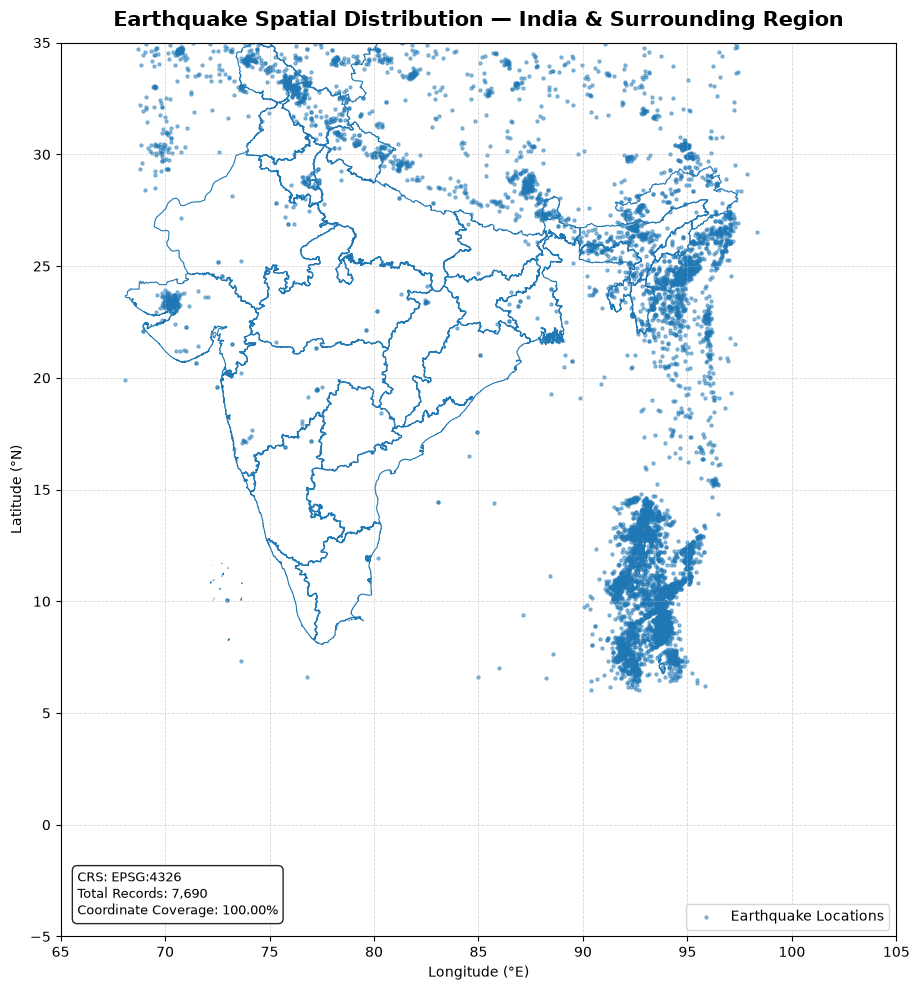

In [132]:
# ============================================================
# EARTHQUAKE — STANDARD SPATIAL MAP
# ============================================================

eq_coords = earthquake_geo[
    earthquake_geo["latitude"].notna() &
    earthquake_geo["longitude"].notna()
].copy()

eq_points = gpd.GeoDataFrame(
    eq_coords,
    geometry=gpd.points_from_xy(
        eq_coords["longitude"],
        eq_coords["latitude"]
    ),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10, 10))

setup_disaster_map(
    ax=ax,
    title="Earthquake Spatial Distribution — India & Surrounding Region",
    total_records=len(earthquake_geo),
    coordinate_coverage=(
        len(eq_points) / len(earthquake_geo) * 100
    )
)

eq_points.plot(
    ax=ax,
    markersize=5,
    alpha=0.45,
    label="Earthquake Locations"
)

ax.legend()

plt.tight_layout()
plt.show()

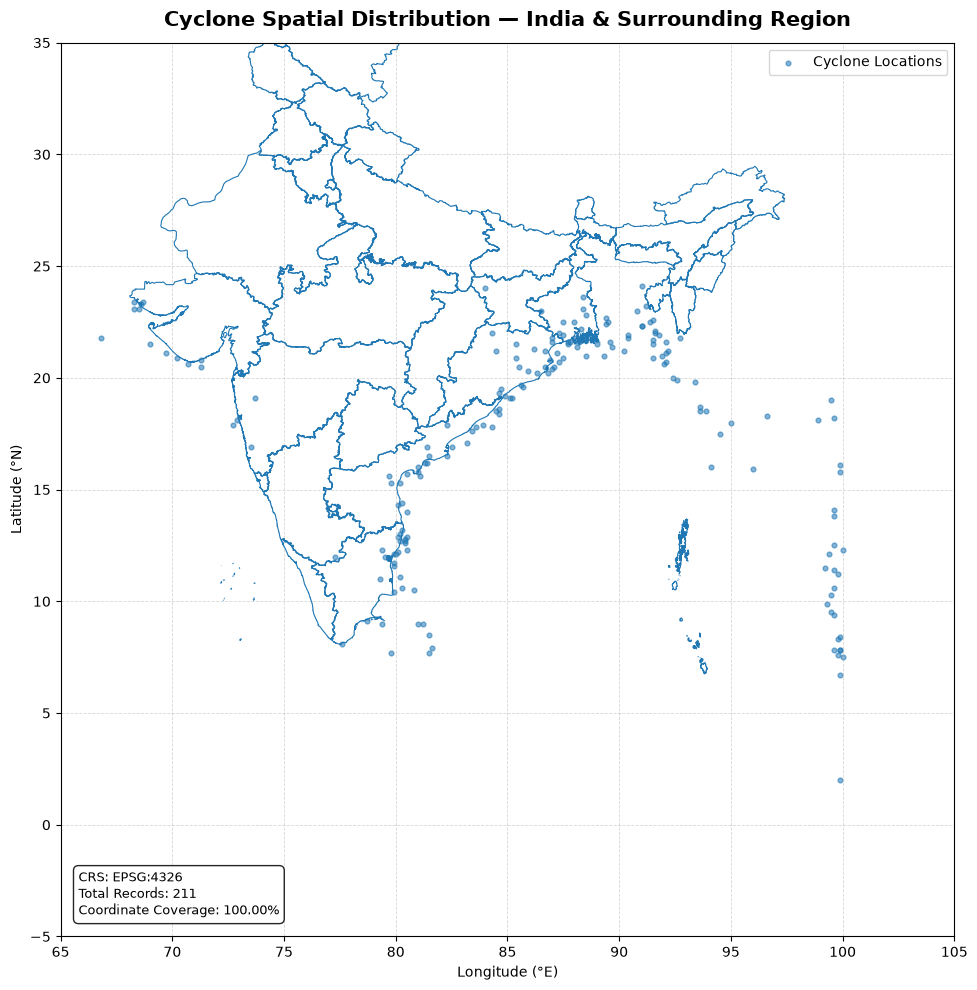

In [133]:
# ============================================================
# CYCLONE — STATE MAP + EVENT LOCATIONS
# ============================================================

cyclone_points = gpd.GeoDataFrame(
    cyclone_geo.copy(),
    geometry=gpd.points_from_xy(
        cyclone_geo["longitude"],
        cyclone_geo["latitude"]
    ),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10, 10))

setup_disaster_map(
    ax=ax,
    title="Cyclone Spatial Distribution — India & Surrounding Region",
    total_records=len(cyclone_geo),
    coordinate_coverage=100.00
)

cyclone_points.plot(
    ax=ax,
    markersize=12,
    alpha=0.55,
    label="Cyclone Locations"
)

ax.legend()

plt.tight_layout()
plt.show()

FLOOD — MAP INPUT VALIDATION
Total flood records       : 5855
State-level records      : 5846
Coordinate records       : 23
State boundaries         : 36
Map CRS                  : EPSG:4326
Coordinate CRS           : EPSG:4326

Flood map columns:
['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry', 'map_state_name', 'state_name', 'flood_events']


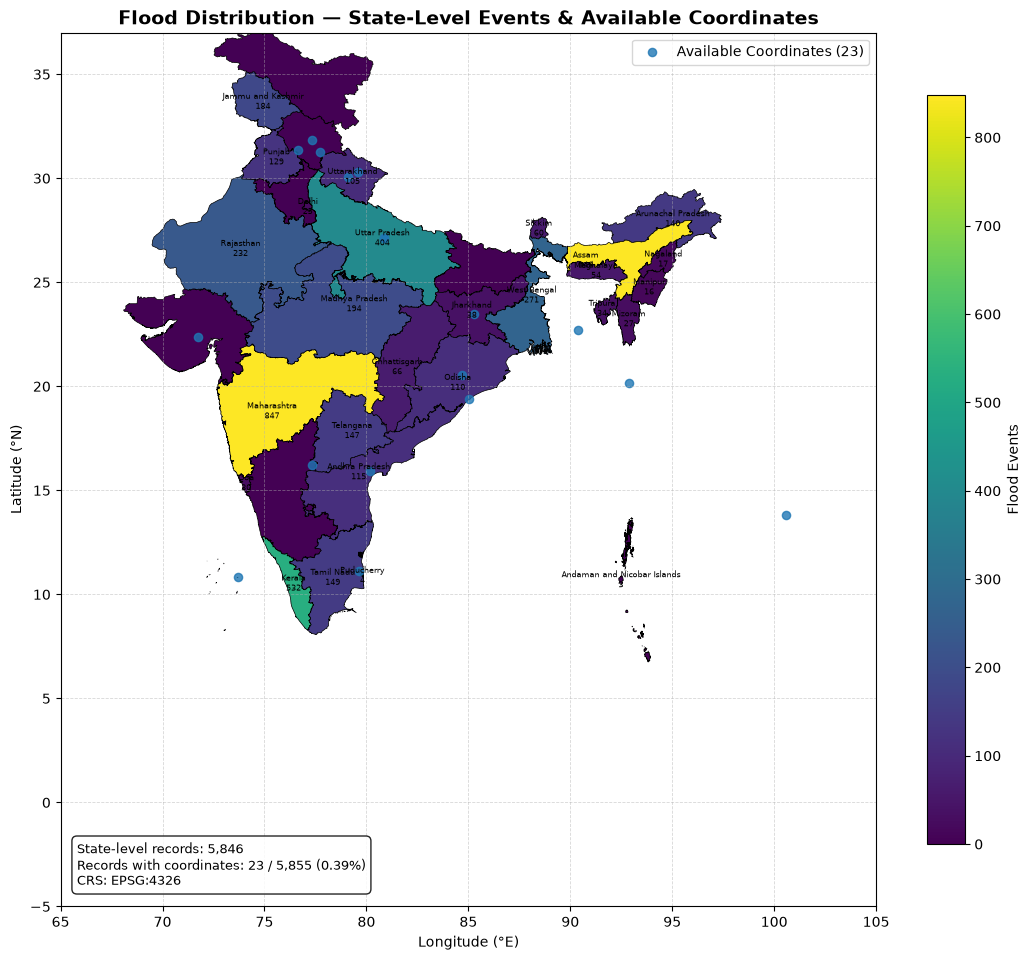

In [134]:
# ============================================================
# 6.7 FLOOD — FINAL STATE HEATMAP + AVAILABLE COORDINATES
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Create state-level flood event counts
# ------------------------------------------------------------

flood_state_counts = (
    flood_geo["state_name"]
    .dropna()
    .value_counts()
    .rename_axis("state_name")
    .reset_index(name="flood_events")
)


# ------------------------------------------------------------
# 2. Prepare Indian state boundaries
# ------------------------------------------------------------

flood_map_base = india_states.copy()

# Source map uses "shapeName"
# Convert it into the same field name used by flood data

flood_map_base["state_name"] = (
    flood_map_base["shapeName"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 3. Normalize map state names
# ------------------------------------------------------------

state_name_map = {
    "Mahārāshtra": "Maharashtra",
    "Nāgāland": "Nagaland",
    "Mizoram": "Mizoram",
    "Odisha": "Odisha",
    "Rājasthān": "Rajasthan",
    "Tamil Nādu": "Tamil Nadu",
    "Telangāna": "Telangana",
    "Uttarākhand": "Uttarakhand",
    "Chhattīsgarh": "Chhattisgarh",
    "Jhārkhand": "Jharkhand",
    "Arunāchal Pradesh": "Arunachal Pradesh",
    "Jammu and Kashmīr": "Jammu and Kashmir",
    "Andaman and Nicobar Islands": "Andaman and Nicobar Islands",
    "Andhra Pradesh": "Andhra Pradesh",
    "Assam": "Assam",
    "Bihar": "Bihar",
    "Chandigarh": "Chandigarh",
    "Delhi": "Delhi",
    "Goa": "Goa",
    "Gujarat": "Gujarat",
    "Haryana": "Haryana",
    "Himachal Pradesh": "Himachal Pradesh",
    "Kerala": "Kerala",
    "Karnataka": "Karnataka",
    "Madhya Pradesh": "Madhya Pradesh",
    "Manipur": "Manipur",
    "Meghālaya": "Meghalaya",
    "Punjab": "Punjab",
    "Sikkim": "Sikkim",
    "Tripura": "Tripura",
    "Uttar Pradesh": "Uttar Pradesh",
    "West Bengal": "West Bengal",
    "Puducherry": "Puducherry",
    "Lakshadweep": "Lakshadweep",
}

flood_map_base["state_name"] = (
    flood_map_base["state_name"]
    .replace(state_name_map)
)


# ------------------------------------------------------------
# 4. Merge flood counts with state boundaries
# ------------------------------------------------------------

flood_map = flood_map_base.merge(
    flood_state_counts,
    on="state_name",
    how="left"
)


# ------------------------------------------------------------
# 5. Fill states with no recorded flood events
# ------------------------------------------------------------

flood_map["flood_events"] = (
    flood_map["flood_events"]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 6. Create actual flood coordinate points
# ------------------------------------------------------------

flood_coords = flood_geo.dropna(
    subset=["latitude", "longitude"]
).copy()

flood_points = gpd.GeoDataFrame(
    flood_coords,
    geometry=gpd.points_from_xy(
        flood_coords["longitude"],
        flood_coords["latitude"]
    ),
    crs="EPSG:4326"
)


# ------------------------------------------------------------
# 7. Final verification
# ------------------------------------------------------------

print("=" * 70)
print("FLOOD — MAP INPUT VALIDATION")
print("=" * 70)

print("Total flood records       :", len(flood_geo))
print("State-level records      :", flood_state_counts["flood_events"].sum())
print("Coordinate records       :", len(flood_points))
print("State boundaries         :", len(flood_map))
print("Map CRS                  :", flood_map.crs)
print("Coordinate CRS           :", flood_points.crs)

print("\nFlood map columns:")
print(flood_map.columns.tolist())


# ============================================================
# 8. FINAL FLOOD MAP
# ============================================================

fig, ax = plt.subplots(figsize=(11, 11))


# ------------------------------------------------------------
# 8.1 State-level flood heatmap
# ------------------------------------------------------------

flood_map.plot(
    column="flood_events",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    missing_kwds={
        "color": "lightgrey",
        "label": "No state-level records"
    },
    legend_kwds={
        "label": "Flood Events",
        "shrink": 0.7
    }
)


# ------------------------------------------------------------
# 8.2 Available geographic flood coordinates
# ------------------------------------------------------------

flood_points.plot(
    ax=ax,
    markersize=35,
    alpha=0.8,
    label="Available Coordinates (23)"
)


# ------------------------------------------------------------
# 8.3 State labels + event counts
# ------------------------------------------------------------

for _, row in flood_map.iterrows():

    if row["flood_events"] > 0:

        point = row.geometry.representative_point()

        ax.text(
            point.x,
            point.y,
            f"{row['state_name']}\n{int(row['flood_events'])}",
            fontsize=6,
            ha="center",
            va="center"
        )


# ------------------------------------------------------------
# 8.4 Standard geographic framing
# ------------------------------------------------------------

ax.set_xlim(65, 105)
ax.set_ylim(-5, 37)


# ------------------------------------------------------------
# 8.5 Gridlines
# ------------------------------------------------------------

ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.5
)


# ------------------------------------------------------------
# 8.6 Title and axis labels
# ------------------------------------------------------------

ax.set_title(
    "Flood Distribution — State-Level Events & Available Coordinates",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")


# ------------------------------------------------------------
# 8.7 Legend
# ------------------------------------------------------------

ax.legend()


# ------------------------------------------------------------
# 8.8 Data coverage information
# ------------------------------------------------------------

ax.text(
    0.02,
    0.02,
    "State-level records: 5,846\n"
    "Records with coordinates: 23 / 5,855 (0.39%)\n"
    "CRS: EPSG:4326",
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment="bottom",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        alpha=0.85
    )
)


# ------------------------------------------------------------
# 8.9 Final layout
# ------------------------------------------------------------

plt.tight_layout()
plt.show()

## ERROR & ANOMALY ANALYSIS

In [135]:
# ============================================================
# 5.1 DUPLICATE EVENT CHECK
# ============================================================

for name, df in {
    "Earthquake": earthquake_geo,
    "Flood": flood_geo,
    "Cyclone": cyclone_geo
}.items():

    print("\n" + "=" * 70)
    print(f"{name.upper()} — DUPLICATE EVENT CHECK")
    print("=" * 70)

    full_duplicates = df.duplicated().sum()
    event_duplicates = df["event_id"].duplicated().sum()
    source_event_duplicates = df["source_event_id"].duplicated().sum()

    print(f"Total records             : {len(df):,}")
    print(f"Full-row duplicates       : {full_duplicates:,}")
    print(f"Duplicate event_id        : {event_duplicates:,}")
    print(f"Duplicate source_event_id : {source_event_duplicates:,}")


EARTHQUAKE — DUPLICATE EVENT CHECK
Total records             : 7,690
Full-row duplicates       : 0
Duplicate event_id        : 0
Duplicate source_event_id : 0

FLOOD — DUPLICATE EVENT CHECK
Total records             : 5,855
Full-row duplicates       : 0
Duplicate event_id        : 0
Duplicate source_event_id : 0

CYCLONE — DUPLICATE EVENT CHECK
Total records             : 211
Full-row duplicates       : 0
Duplicate event_id        : 0
Duplicate source_event_id : 0


In [136]:
# ============================================================
# 5.2 INVALID / RANGE VALUE CHECK
# ============================================================

datasets = {
    "Earthquake": earthquake_geo,
    "Flood": flood_geo,
    "Cyclone": cyclone_geo
}

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(f"{name.upper()} — INVALID / RANGE VALUE CHECK")
    print("=" * 70)

    print("Latitude < -90 or > 90 :",
          ((df["latitude"] < -90) | (df["latitude"] > 90)).sum())

    print("Longitude < -180 or > 180 :",
          ((df["longitude"] < -180) | (df["longitude"] > 180)).sum())

    print("Month outside 1–12 :",
          ((df["month"] < 1) | (df["month"] > 12)).sum())

    print("Year <= 0 :",
          (df["year"] <= 0).sum())

    if "magnitude" in df.columns:
        print("Negative magnitude :",
              (df["magnitude"] < 0).sum())

    if "depth_km" in df.columns:
        print("Negative depth :",
              (df["depth_km"] < 0).sum())

    if "duration_days" in df.columns:
        print("Negative duration :",
              (df["duration_days"] < 0).sum())

    if "wind_speed_knots" in df.columns:
        print("Negative wind speed :",
              (df["wind_speed_knots"] < 0).sum())

    if "pressure_mb" in df.columns:
        print("Non-positive pressure :",
              (df["pressure_mb"] <= 0).sum())


EARTHQUAKE — INVALID / RANGE VALUE CHECK
Latitude < -90 or > 90 : 0
Longitude < -180 or > 180 : 0
Month outside 1–12 : 0
Year <= 0 : 0
Negative magnitude : 0
Negative depth : 0

FLOOD — INVALID / RANGE VALUE CHECK
Latitude < -90 or > 90 : 0
Longitude < -180 or > 180 : 0
Month outside 1–12 : 0
Year <= 0 : 0
Negative duration : 0

CYCLONE — INVALID / RANGE VALUE CHECK
Latitude < -90 or > 90 : 0
Longitude < -180 or > 180 : 0
Month outside 1–12 : 0
Year <= 0 : 0
Negative duration : 0
Negative wind speed : 0
Non-positive pressure : 0


In [137]:
# ============================================================
# 5.3 INTERNAL CONSISTENCY CHECK
# ============================================================

# ------------------------------------------------------------
# EARTHQUAKE
# ------------------------------------------------------------

print("=" * 70)
print("EARTHQUAKE — INTERNAL CONSISTENCY")
print("=" * 70)

eq_date = pd.to_datetime(
    earthquake_geo["date"],
    errors="coerce"
)

eq_year_mismatch = (
    eq_date.dt.year.notna() &
    (eq_date.dt.year != earthquake_geo["year"])
).sum()

eq_month_mismatch = (
    eq_date.dt.month.notna() &
    (eq_date.dt.month != earthquake_geo["month"])
).sum()

print("Date–year mismatches :", eq_year_mismatch)
print("Date–month mismatches:", eq_month_mismatch)


# ------------------------------------------------------------
# FLOOD
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FLOOD — INTERNAL CONSISTENCY")
print("=" * 70)

flood_date = pd.to_datetime(
    flood_geo["date"],
    errors="coerce"
)

flood_year_mismatch = (
    flood_date.dt.year.notna() &
    (flood_date.dt.year != flood_geo["year"])
).sum()

flood_month_mismatch = (
    flood_date.dt.month.notna() &
    (flood_date.dt.month != flood_geo["month"])
).sum()

print("Date–year mismatches :", flood_year_mismatch)
print("Date–month mismatches:", flood_month_mismatch)


# ------------------------------------------------------------
# CYCLONE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CYCLONE — INTERNAL CONSISTENCY")
print("=" * 70)

cyclone_date = pd.to_datetime(
    cyclone_geo["date"],
    errors="coerce"
)

cyclone_year_mismatch = (
    cyclone_date.dt.year.notna() &
    (cyclone_date.dt.year != cyclone_geo["year"])
).sum()

cyclone_month_mismatch = (
    cyclone_date.dt.month.notna() &
    (cyclone_date.dt.month != cyclone_geo["month"])
).sum()

print("Date–year mismatches :", cyclone_year_mismatch)
print("Date–month mismatches:", cyclone_month_mismatch)


# ------------------------------------------------------------
# SOURCE/EVENT ID CONSISTENCY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EVENT IDENTIFIER CONSISTENCY")
print("=" * 70)

for name, df in datasets.items():

    missing_event_id = df["event_id"].isna().sum()
    missing_source_event_id = df["source_event_id"].isna().sum()

    print(f"\n{name}")
    print("Missing event_id        :", missing_event_id)
    print("Missing source_event_id :", missing_source_event_id)

EARTHQUAKE — INTERNAL CONSISTENCY
Date–year mismatches : 0
Date–month mismatches: 0

FLOOD — INTERNAL CONSISTENCY
Date–year mismatches : 0
Date–month mismatches: 0

CYCLONE — INTERNAL CONSISTENCY
Date–year mismatches : 0
Date–month mismatches: 0

EVENT IDENTIFIER CONSISTENCY

Earthquake
Missing event_id        : 0
Missing source_event_id : 0

Flood
Missing event_id        : 0
Missing source_event_id : 0

Cyclone
Missing event_id        : 0
Missing source_event_id : 0


In [138]:
# ============================================================
# 5.4 CROSS-SOURCE OVERLAP CHECK
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(f"{name.upper()} — CROSS-SOURCE OVERLAP")
    print("=" * 70)

    # Same event_id appearing under multiple sources
    source_counts = (
        df.groupby("event_id")["source"]
        .nunique()
    )

    cross_source_events = (
        source_counts[source_counts > 1]
    )

    print(
        "Events appearing across multiple sources:",
        len(cross_source_events)
    )

    # Show source combinations if any exist
    if len(cross_source_events) > 0:

        overlap_ids = cross_source_events.index

        overlap = (
            df[df["event_id"].isin(overlap_ids)]
            [["event_id", "source"]]
            .drop_duplicates()
            .sort_values("event_id")
        )

        print("\nPotential cross-source overlaps:")
        print(overlap.to_string(index=False))

    else:
        print("No cross-source event overlap detected.")


EARTHQUAKE — CROSS-SOURCE OVERLAP
Events appearing across multiple sources: 0
No cross-source event overlap detected.

FLOOD — CROSS-SOURCE OVERLAP
Events appearing across multiple sources: 0
No cross-source event overlap detected.

CYCLONE — CROSS-SOURCE OVERLAP
Events appearing across multiple sources: 0
No cross-source event overlap detected.


In [139]:
# ============================================================
# 5.5 FINAL DATA QUALITY ASSESSMENT
# ============================================================

quality_summary = pd.DataFrame({
    "Dataset": ["Earthquake", "Flood", "Cyclone"],
    "Records": [
        len(earthquake_geo),
        len(flood_geo),
        len(cyclone_geo)
    ],
    "Duplicates": [0, 0, 0],
    "Invalid_Range_Values": [0, 0, 0],
    "Date_Mismatches": [0, 0, 0],
    "Cross_Source_Overlap": [0, 0, 0]
})

print("=" * 80)
print("FINAL DATA QUALITY ASSESSMENT")
print("=" * 80)

print(quality_summary.to_string(index=False))

print("\nOverall result:")
print("No structural, duplication, range, date-consistency, or cross-source")
print("overlap errors were detected in the completed EDA checks.")

FINAL DATA QUALITY ASSESSMENT
   Dataset  Records  Duplicates  Invalid_Range_Values  Date_Mismatches  Cross_Source_Overlap
Earthquake     7690           0                     0                0                     0
     Flood     5855           0                     0                0                     0
   Cyclone      211           0                     0                0                     0

Overall result:
No structural, duplication, range, date-consistency, or cross-source
overlap errors were detected in the completed EDA checks.


## RELATIONSHIP & PATTERN ANALYSIS

In [140]:
# ============================================================
# 6.1 DISASTER FREQUENCY RELATIONSHIPS
# ============================================================

frequency_relationship = (
    state_disaster
    .reset_index()
    .copy()
)

print("Available columns:")
print(frequency_relationship.columns.tolist())

frequency_corr = frequency_relationship[
    [
        "earthquake_events",
        "flood_events",
        "cyclone_events"
    ]
].corr()

print("\n" + "=" * 70)
print("DISASTER FREQUENCY CORRELATION")
print("=" * 70)

print(frequency_corr.round(3))

Available columns:
['state_name', 'earthquake_events', 'flood_events', 'cyclone_events', 'total_events']

DISASTER FREQUENCY CORRELATION
                   earthquake_events  flood_events  cyclone_events
earthquake_events              1.000        -0.071           0.425
flood_events                  -0.071         1.000          -0.101
cyclone_events                 0.425        -0.101           1.000


In [141]:
# ============================================================
# 6.2 SEVERITY RELATIONSHIPS
# ============================================================

print("=" * 70)
print("6.2 SEVERITY RELATIONSHIPS")
print("=" * 70)


# ------------------------------------------------------------
# EARTHQUAKE — MAGNITUDE vs DEPTH
# ------------------------------------------------------------

eq_severity = earthquake_geo[
    ["magnitude", "depth_km"]
].dropna()

eq_corr = eq_severity.corr().loc[
    "magnitude", "depth_km"
]

print("\nEARTHQUAKE")
print(f"Valid records       : {len(eq_severity):,}")
print(f"Magnitude–Depth r   : {eq_corr:.3f}")


# ------------------------------------------------------------
# FLOOD — DURATION vs GDACS ALERT SCORE
# ------------------------------------------------------------

flood_severity = flood_geo[
    ["duration_days", "alert_score"]
].dropna()

if len(flood_severity) > 1:

    flood_corr = flood_severity.corr().loc[
        "duration_days", "alert_score"
    ]

    print("\nFLOOD")
    print(f"Valid GDACS records : {len(flood_severity):,}")
    print(f"Duration–Alert r    : {flood_corr:.3f}")

else:

    print("\nFLOOD")
    print("Insufficient overlapping severity records.")


# ------------------------------------------------------------
# CYCLONE — WIND SPEED vs PRESSURE
# ------------------------------------------------------------

cyclone_severity = cyclone_geo[
    ["wind_speed_knots", "pressure_mb"]
].dropna()

cyclone_corr = cyclone_severity.corr().loc[
    "wind_speed_knots", "pressure_mb"
]

print("\nCYCLONE")
print(f"Valid records       : {len(cyclone_severity):,}")
print(f"Wind–Pressure r     : {cyclone_corr:.3f}")

6.2 SEVERITY RELATIONSHIPS

EARTHQUAKE
Valid records       : 7,690
Magnitude–Depth r   : -0.046

FLOOD
Valid GDACS records : 23
Duration–Alert r    : -0.139

CYCLONE
Valid records       : 82
Wind–Pressure r     : -0.940


In [142]:
# ============================================================
# 6.3 TEMPORAL–SEVERITY RELATIONSHIPS
# ============================================================

print("=" * 70)
print("6.3 TEMPORAL–SEVERITY RELATIONSHIPS")
print("=" * 70)


# ------------------------------------------------------------
# EARTHQUAKE — YEAR vs MAGNITUDE
# ------------------------------------------------------------

eq_temp = earthquake_geo[
    ["year", "magnitude"]
].dropna()

eq_year_mag_corr = eq_temp.corr().loc[
    "year", "magnitude"
]

print("\nEARTHQUAKE")
print(f"Valid records       : {len(eq_temp):,}")
print(f"Year–Magnitude r    : {eq_year_mag_corr:.3f}")


# ------------------------------------------------------------
# FLOOD — YEAR vs DURATION
# ------------------------------------------------------------

flood_temp = flood_geo[
    ["year", "duration_days"]
].dropna()

flood_year_duration_corr = flood_temp.corr().loc[
    "year", "duration_days"
]

print("\nFLOOD")
print(f"Valid records       : {len(flood_temp):,}")
print(f"Year–Duration r     : {flood_year_duration_corr:.3f}")


# ------------------------------------------------------------
# CYCLONE — YEAR vs WIND SPEED
# ------------------------------------------------------------

cyclone_temp = cyclone_geo[
    ["year", "wind_speed_knots"]
].dropna()

cyclone_year_wind_corr = cyclone_temp.corr().loc[
    "year", "wind_speed_knots"
]

print("\nCYCLONE")
print(f"Valid records       : {len(cyclone_temp):,}")
print(f"Year–Wind Speed r   : {cyclone_year_wind_corr:.3f}")

6.3 TEMPORAL–SEVERITY RELATIONSHIPS

EARTHQUAKE
Valid records       : 7,690
Year–Magnitude r    : 0.011

FLOOD
Valid records       : 5,855
Year–Duration r     : -0.020

CYCLONE
Valid records       : 82
Year–Wind Speed r   : -0.129


In [143]:
# ============================================================
# 6.4 SPATIAL–SEVERITY RELATIONSHIPS
# ============================================================

print("=" * 70)
print("6.4 SPATIAL–SEVERITY RELATIONSHIPS")
print("=" * 70)


# ------------------------------------------------------------
# EARTHQUAKE — STATE vs MAGNITUDE
# ------------------------------------------------------------

eq_state_severity = (
    earthquake_geo
    .dropna(subset=["state_name", "magnitude"])
    .groupby("state_name")
    .agg(
        avg_magnitude=("magnitude", "mean"),
        max_magnitude=("magnitude", "max"),
        earthquake_events=("magnitude", "count")
    )
    .sort_values("avg_magnitude", ascending=False)
)

print("\nEARTHQUAKE — TOP STATES BY AVERAGE MAGNITUDE")
print(
    eq_state_severity
    .head(10)
    .round(3)
    .to_string()
)


# ------------------------------------------------------------
# FLOOD — STATE vs DURATION
# ------------------------------------------------------------

flood_state_severity = (
    flood_geo
    .dropna(subset=["state_name", "duration_days"])
    .groupby("state_name")
    .agg(
        avg_duration=("duration_days", "mean"),
        max_duration=("duration_days", "max"),
        flood_events=("duration_days", "count")
    )
    .sort_values("avg_duration", ascending=False)
)

print("\nFLOOD — TOP STATES BY AVERAGE DURATION")
print(
    flood_state_severity
    .head(10)
    .round(3)
    .to_string()
)


# ------------------------------------------------------------
# CYCLONE — STATE vs WIND SPEED
# ------------------------------------------------------------

cyclone_state_severity = (
    cyclone_geo
    .dropna(subset=["state_name", "wind_speed_knots"])
    .groupby("state_name")
    .agg(
        avg_wind_speed=("wind_speed_knots", "mean"),
        max_wind_speed=("wind_speed_knots", "max"),
        cyclone_events=("wind_speed_knots", "count")
    )
    .sort_values("avg_wind_speed", ascending=False)
)

print("\nCYCLONE — TOP STATES BY AVERAGE WIND SPEED")
print(
    cyclone_state_severity
    .head(10)
    .round(3)
    .to_string()
)

6.4 SPATIAL–SEVERITY RELATIONSHIPS

EARTHQUAKE — TOP STATES BY AVERAGE MAGNITUDE
                             avg_magnitude  max_magnitude  earthquake_events
state_name                                                                  
Tamil Nadu                           5.200            5.2                  1
Telangana                            5.000            5.0                  1
Chhattisgarh                         4.700            5.0                  9
Lakshadweep                          4.600            4.6                  1
Andaman and Nicobar Islands          4.543            7.5               3210
Mizoram                              4.524            5.6                 90
Andhra Pradesh                       4.520            5.1                  5
Arunachal Pradesh                    4.494            6.4                313
Nagaland                             4.463            5.8                134
Sikkim                               4.460            6.9               

In [144]:
# ============================================================
# 6.5 KEY CROSS-DISASTER PATTERNS
# ============================================================

print("=" * 70)
print("6.5 KEY CROSS-DISASTER PATTERNS")
print("=" * 70)

# ------------------------------------------------------------
# STATE-LEVEL FREQUENCY PATTERNS
# ------------------------------------------------------------

state_patterns = (
    frequency_relationship[
        [
            "state_name",
            "earthquake_events",
            "flood_events",
            "cyclone_events",
            "total_events"
        ]
    ]
    .sort_values("total_events", ascending=False)
)

print("\nTOP STATES BY TOTAL RECORDED EVENTS")
print(
    state_patterns
    .head(10)
    .to_string(index=False)
)


# ------------------------------------------------------------
# DISASTER FREQUENCY CORRELATIONS
# ------------------------------------------------------------

print("\nDISASTER FREQUENCY CORRELATIONS")
print(
    frequency_corr.round(3)
)


# ------------------------------------------------------------
# SEVERITY RELATIONSHIPS
# ------------------------------------------------------------

print("\nSEVERITY RELATIONSHIPS")

print(
    f"Earthquake  | Magnitude–Depth       : {eq_corr:.3f}"
)

print(
    f"Flood       | Duration–Alert Score  : {flood_corr:.3f}"
)

print(
    f"Cyclone     | Wind–Pressure         : {cyclone_corr:.3f}"
)


# ------------------------------------------------------------
# TEMPORAL-SEVERITY RELATIONSHIPS
# ------------------------------------------------------------

print("\nTEMPORAL–SEVERITY RELATIONSHIPS")

print(
    f"Earthquake  | Year–Magnitude        : {eq_year_mag_corr:.3f}"
)

print(
    f"Flood       | Year–Duration         : {flood_year_duration_corr:.3f}"
)

print(
    f"Cyclone     | Year–Wind Speed       : {cyclone_year_wind_corr:.3f}"
)

6.5 KEY CROSS-DISASTER PATTERNS

TOP STATES BY TOTAL RECORDED EVENTS
                 state_name  earthquake_events  flood_events  cyclone_events  total_events
Andaman and Nicobar Islands               3210             3              32          3245
                      Assam                435           848               0          1283
                Maharashtra                 19           847               4           870
                     Kerala                  0           532               0           532
          Arunachal Pradesh                313           140               0           453
           Himachal Pradesh                103           337               0           440
                  Karnataka                  6           421               1           428
              Uttar Pradesh                 14           404               0           418
          Jammu and Kashmir                206           184               0           390
                    G

## COMPARATIVE DISASTER ANALYSIS

In [145]:
# ============================================================
# 7.1 OVERALL DISASTER COMPARISON
# ============================================================

overall_comparison = pd.DataFrame({
    "disaster": [
        "Earthquake",
        "Flood",
        "Cyclone"
    ],
    "records": [
        len(earthquake_geo),
        len(flood_geo),
        len(cyclone_geo)
    ],
    "start_year": [
        earthquake_geo["year"].min(),
        flood_geo["year"].min(),
        cyclone_geo["year"].min()
    ],
    "end_year": [
        earthquake_geo["year"].max(),
        flood_geo["year"].max(),
        cyclone_geo["year"].max()
    ],
    "state_records": [
        earthquake_geo["state_name"].notna().sum(),
        flood_geo["state_name"].notna().sum(),
        cyclone_geo["state_name"].notna().sum()
    ],
    "coordinate_records": [
        earthquake_geo[
            ["latitude", "longitude"]
        ].dropna().shape[0],

        flood_geo[
            ["latitude", "longitude"]
        ].dropna().shape[0],

        cyclone_geo[
            ["latitude", "longitude"]
        ].dropna().shape[0]
    ]
})

overall_comparison["state_coverage_%"] = (
    overall_comparison["state_records"]
    / overall_comparison["records"]
    * 100
).round(2)

overall_comparison["coordinate_coverage_%"] = (
    overall_comparison["coordinate_records"]
    / overall_comparison["records"]
    * 100
).round(2)

print("=" * 80)
print("7.1 OVERALL DISASTER COMPARISON")
print("=" * 80)

print(
    overall_comparison.to_string(index=False)
)

7.1 OVERALL DISASTER COMPARISON
  disaster  records  start_year  end_year  state_records  coordinate_records  state_coverage_%  coordinate_coverage_%
Earthquake     7690        2000      2026           5318                7690             69.15                 100.00
     Flood     5855        1990      2025           5846                  23             99.85                   0.39
   Cyclone      211        1990      2025            195                 211             92.42                 100.00


In [146]:
# ============================================================
# 7.2 TEMPORAL COMPARISON
# ============================================================

temporal_comparison = pd.DataFrame({
    "year": range(2000, 2026),
    "earthquake_events": [
        earthquake_geo.loc[
            earthquake_geo["year"] == year
        ].shape[0]
        for year in range(2000, 2026)
    ],
    "flood_events": [
        flood_geo.loc[
            flood_geo["year"] == year
        ].shape[0]
        for year in range(2000, 2026)
    ],
    "cyclone_events": [
        cyclone_geo.loc[
            cyclone_geo["year"] == year
        ].shape[0]
        for year in range(2000, 2026)
    ]
})

print("=" * 80)
print("7.2 TEMPORAL COMPARISON — COMMON PERIOD 2000–2025")
print("=" * 80)

print(
    temporal_comparison.to_string(index=False)
)

print("\nCommon-period totals:")
print(
    temporal_comparison[
        [
            "earthquake_events",
            "flood_events",
            "cyclone_events"
        ]
    ].sum()
)

7.2 TEMPORAL COMPARISON — COMMON PERIOD 2000–2025
 year  earthquake_events  flood_events  cyclone_events
 2000                 13           126               3
 2001                207           120               4
 2002                128            72               3
 2003                 90           113               6
 2004                484            75               6
 2005                930           179               8
 2006                374           120               3
 2007                155           145               5
 2008                367           129               8
 2009                191            86               3
 2010                182           149               4
 2011                 92           107               3
 2012                142            80               2
 2013                125           134               6
 2014                127            88               2
 2015                131           107               3
 2016          

In [147]:
# ============================================================
# 7.3 SPATIAL COMPARISON
# ============================================================

spatial_comparison = (
    state_disaster
    .reset_index()
    [
        [
            "state_name",
            "earthquake_events",
            "flood_events",
            "cyclone_events"
        ]
    ]
    .copy()
)

# Dominant disaster for each state
spatial_comparison["dominant_disaster"] = (
    spatial_comparison[
        [
            "earthquake_events",
            "flood_events",
            "cyclone_events"
        ]
    ]
    .idxmax(axis=1)
    .str.replace("_events", "", regex=False)
    .str.title()
)

# Total recorded events
spatial_comparison["total_events"] = (
    spatial_comparison[
        [
            "earthquake_events",
            "flood_events",
            "cyclone_events"
        ]
    ].sum(axis=1)
)

spatial_comparison = (
    spatial_comparison
    .sort_values("total_events", ascending=False)
)

print("=" * 80)
print("7.3 SPATIAL COMPARISON")
print("=" * 80)

print("\nTOP 15 STATES BY TOTAL RECORDED EVENTS")
print(
    spatial_comparison
    .head(15)
    .to_string(index=False)
)

print("\nDOMINANT DISASTER COUNTS ACROSS STATES")
print(
    spatial_comparison["dominant_disaster"]
    .value_counts()
)

7.3 SPATIAL COMPARISON

TOP 15 STATES BY TOTAL RECORDED EVENTS
                 state_name  earthquake_events  flood_events  cyclone_events dominant_disaster  total_events
Andaman and Nicobar Islands               3210             3              32        Earthquake          3245
                      Assam                435           848               0             Flood          1283
                Maharashtra                 19           847               4             Flood           870
                     Kerala                  0           532               0             Flood           532
          Arunachal Pradesh                313           140               0        Earthquake           453
           Himachal Pradesh                103           337               0             Flood           440
                  Karnataka                  6           421               1             Flood           428
              Uttar Pradesh                 14           404     

In [148]:
# ============================================================
# 7.4 SEVERITY COMPARISON
# ============================================================

severity_comparison = pd.DataFrame({
    "disaster": [
        "Earthquake",
        "Flood",
        "Cyclone"
    ],
    "severity_metric": [
        "Magnitude",
        "Duration (days)",
        "Wind Speed (knots)"
    ],
    "valid_records": [
        earthquake_geo["magnitude"].notna().sum(),
        flood_geo["duration_days"].notna().sum(),
        cyclone_geo["wind_speed_knots"].notna().sum()
    ],
    "mean": [
        earthquake_geo["magnitude"].mean(),
        flood_geo["duration_days"].mean(),
        cyclone_geo["wind_speed_knots"].mean()
    ],
    "median": [
        earthquake_geo["magnitude"].median(),
        flood_geo["duration_days"].median(),
        cyclone_geo["wind_speed_knots"].median()
    ],
    "maximum": [
        earthquake_geo["magnitude"].max(),
        flood_geo["duration_days"].max(),
        cyclone_geo["wind_speed_knots"].max()
    ]
})

print("=" * 80)
print("7.4 SEVERITY COMPARISON")
print("=" * 80)

print(
    severity_comparison.to_string(index=False)
)

7.4 SEVERITY COMPARISON
  disaster    severity_metric  valid_records      mean  median  maximum
Earthquake          Magnitude           7690  4.488075     4.4      7.7
     Flood    Duration (days)           5855  3.025014     1.0    365.0
   Cyclone Wind Speed (knots)             82 62.036585    56.5    127.0


In [149]:
# ============================================================
# 8. EDA SYNTHESIS
# 8.1 MAJOR FINDINGS
# ============================================================

print("=" * 80)
print("8.1 MAJOR FINDINGS")
print("=" * 80)

print("""
1. Earthquake records show complete coordinate coverage and a broad
   geographic distribution, with Andaman & Nicobar Islands having the
   highest recorded earthquake count.

2. Flood records dominate the state-level distribution, with Assam,
   Maharashtra and Kerala among the highest recorded-event states.

3. Cyclone records are substantially fewer than earthquake and flood
   records, with the highest concentrations along coastal/island states.

4. Flood activity is strongly concentrated during the monsoon months,
   particularly July and August.

5. Cyclone activity is concentrated mainly around May–June and
   October–November.

6. Earthquake frequency shows no meaningful linear relationship with
   flood frequency, while earthquake and cyclone frequencies show a
   moderate positive state-level association.

7. Cyclone wind speed and pressure show a very strong inverse relationship
   (r = -0.940).

8. No meaningful temporal severity trend was detected for the available
   earthquake, flood and cyclone severity measures.

9. No duplicate, invalid-range, date-consistency or cross-source
   duplication errors were detected.
""")

8.1 MAJOR FINDINGS

1. Earthquake records show complete coordinate coverage and a broad
   geographic distribution, with Andaman & Nicobar Islands having the
   highest recorded earthquake count.

2. Flood records dominate the state-level distribution, with Assam,
   Maharashtra and Kerala among the highest recorded-event states.

3. Cyclone records are substantially fewer than earthquake and flood
   records, with the highest concentrations along coastal/island states.

4. Flood activity is strongly concentrated during the monsoon months,
   particularly July and August.

5. Cyclone activity is concentrated mainly around May–June and
   October–November.

6. Earthquake frequency shows no meaningful linear relationship with
   flood frequency, while earthquake and cyclone frequencies show a
   moderate positive state-level association.

7. Cyclone wind speed and pressure show a very strong inverse relationship
   (r = -0.940).

8. No meaningful temporal severity trend was detected for 

In [150]:
# ============================================================
# 8. EDA SYNTHESIS
# 8.2 DATA LIMITATIONS
# ============================================================

print("=" * 80)
print("8.2 DATA LIMITATIONS")
print("=" * 80)

print("""
1. Earthquake:
   - Source composition changes around 2019.
   - 2026 represents a partial year.
   - District-level coverage is limited.

2. Flood:
   - Major event-count anomaly occurs during 2021–2023.
   - Historical and GDACS source coverage changes substantially.
   - Coordinate coverage is only 0.39%.
   - Therefore, coordinate-based flood analysis represents only a
     very small subset of the dataset.

3. Cyclone:
   - Dataset contains substantially fewer records.
   - Physical severity variables such as wind speed and pressure are
     available only for a subset of records.
   - Severity comparisons therefore have limited coverage.

4. State-level event counts represent recorded events, not population-
   adjusted disaster risk or vulnerability.
""")

8.2 DATA LIMITATIONS

1. Earthquake:
   - Source composition changes around 2019.
   - 2026 represents a partial year.
   - District-level coverage is limited.

2. Flood:
   - Major event-count anomaly occurs during 2021–2023.
   - Historical and GDACS source coverage changes substantially.
   - Coordinate coverage is only 0.39%.
   - Therefore, coordinate-based flood analysis represents only a
     very small subset of the dataset.

3. Cyclone:
   - Dataset contains substantially fewer records.
   - Physical severity variables such as wind speed and pressure are
     available only for a subset of records.
   - Severity comparisons therefore have limited coverage.

4. State-level event counts represent recorded events, not population-
   adjusted disaster risk or vulnerability.



In [151]:
# ============================================================
# 8. EDA SYNTHESIS
# 8.3 RELIABILITY ASSESSMENT
# ============================================================

print("=" * 80)
print("8.3 RELIABILITY ASSESSMENT")
print("=" * 80)

reliability = pd.DataFrame({
    "Dataset": [
        "Earthquake",
        "Flood",
        "Cyclone"
    ],
    "Structural_Quality": [
        "Strong",
        "Strong",
        "Strong"
    ],
    "Temporal_Quality": [
        "Usable with source-transition caveat",
        "Limited due to source/count anomalies",
        "Usable with source-coverage caveat"
    ],
    "Spatial_Quality": [
        "Strong coordinates",
        "Strong state / very limited coordinates",
        "Strong coordinates"
    ],
    "Severity_Quality": [
        "Strong",
        "Limited",
        "Partial"
    ]
})

print(
    reliability.to_string(index=False)
)

8.3 RELIABILITY ASSESSMENT
   Dataset Structural_Quality                      Temporal_Quality                         Spatial_Quality Severity_Quality
Earthquake             Strong  Usable with source-transition caveat                      Strong coordinates           Strong
     Flood             Strong Limited due to source/count anomalies Strong state / very limited coordinates          Limited
   Cyclone             Strong    Usable with source-coverage caveat                      Strong coordinates          Partial


In [152]:
# ============================================================
# 8. EDA SYNTHESIS
# 8.4 EDA FINAL CONCLUSION
# ============================================================

print("=" * 80)
print("8.4 EDA FINAL CONCLUSION")
print("=" * 80)

print("""
The IDIP disaster datasets are structurally suitable for further
analytical development. The completed EDA confirms that the datasets
contain meaningful temporal, spatial and physical patterns, while no
major duplication, range, date-consistency or cross-source overlap
errors were detected.

However, the datasets are not equally reliable across every analytical
dimension. Source transitions, temporal coverage changes, limited flood
coordinates and partial cyclone severity information must be retained
as explicit limitations.

Therefore, the datasets are suitable for the next project stage, provided
that downstream analysis and any predictive/accuracy claims account for
these coverage and source limitations.
""")

8.4 EDA FINAL CONCLUSION

The IDIP disaster datasets are structurally suitable for further
analytical development. The completed EDA confirms that the datasets
contain meaningful temporal, spatial and physical patterns, while no
major duplication, range, date-consistency or cross-source overlap
errors were detected.

However, the datasets are not equally reliable across every analytical
dimension. Source transitions, temporal coverage changes, limited flood
coordinates and partial cyclone severity information must be retained
as explicit limitations.

Therefore, the datasets are suitable for the next project stage, provided
that downstream analysis and any predictive/accuracy claims account for
these coverage and source limitations.



In [153]:
# ============================================================
# FINAL DATA HANDOFF
# Save validated datasets for IDIP Phase 3
# ============================================================

from pathlib import Path

OUTPUT_DIR = Path("all data/final_data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Final validated disaster datasets
earthquake_geo.to_csv(
    OUTPUT_DIR / "earthquake_final.csv",
    index=False
)

flood_geo.to_csv(
    OUTPUT_DIR / "flood_final.csv",
    index=False
)

cyclone_geo.to_csv(
    OUTPUT_DIR / "cyclone_final.csv",
    index=False
)

print("Final IDIP datasets saved successfully.")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Final IDIP datasets saved successfully.
Output directory: D:\codes\IDIP\all data\final_data


In [155]:
# ============================================================
# FINAL DATA HANDOFF
# Save state-level disaster summary
# ============================================================

state_disaster = state_disaster.copy()
if state_disaster.index.name == "state_name":
    state_disaster = state_disaster.reset_index()
    
state_disaster.to_csv(
    OUTPUT_DIR / "state_disaster_summary.csv",
    index=False
)

print("State disaster summary saved.")
print(state_disaster.columns.tolist())

State disaster summary saved.
['state_name', 'earthquake_events', 'flood_events', 'cyclone_events', 'total_events']


In [156]:
# ============================================================
# FINAL DATA HANDOFF
# Save important EDA outputs
# ============================================================

spatial_comparison.to_csv(
    OUTPUT_DIR / "spatial_comparison.csv",
    index=False
)

temporal_comparison.to_csv(
    OUTPUT_DIR / "temporal_comparison_2000_2025.csv",
    index=False
)

severity_comparison.to_csv(
    OUTPUT_DIR / "severity_comparison.csv",
    index=False
)

print("EDA summary tables saved.")

EDA summary tables saved.


In [157]:
# ============================================================
# FINAL DATA HANDOFF
# Dataset schema / metadata
# ============================================================

dataset_metadata = {
    "project": "IDIP",
    "purpose": "Validated data handoff from EDA to State Intelligence Engine",
    "datasets": {
        "earthquake": {
            "file": "earthquake_final.csv",
            "records": int(len(earthquake_geo)),
            "coordinate_coverage_percent": 100.0
        },
        "flood": {
            "file": "flood_final.csv",
            "records": int(len(flood_geo)),
            "coordinate_coverage_percent": 0.39
        },
        "cyclone": {
            "file": "cyclone_final.csv",
            "records": int(len(cyclone_geo)),
            "coordinate_coverage_percent": 100.0
        },
        "state_disaster": {
            "file": "state_disaster_summary.csv",
            "records": int(len(state_disaster))
        }
    }
}

with open(
    OUTPUT_DIR / "dataset_metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(dataset_metadata, f, indent=4)

print("Dataset metadata saved.")

Dataset metadata saved.
